<a href="https://colab.research.google.com/github/Sievv/Sievv/blob/main/CD_HIT_METHOD%20and%20Data%20Visualization%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Active columns: ['Pathogen', 'Sequence', 'Activity', 'Length']
Inactive columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Sequence', 'Label', 'Length']

Counts
K. pneumoniae active: 113
E. coli active: 98
P. aeruginosa active: 94
Total active: 305
Total inactive: 363
Total dataset: 668


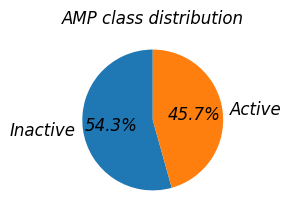

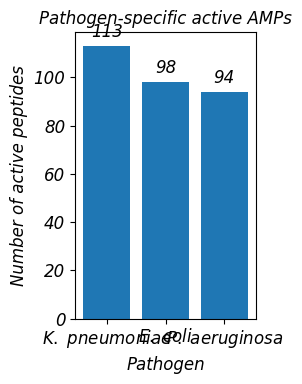

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================
active_file = "/content/drive/MyDrive/AMP-ML/data/raw/AMP_active_raw_data_one_sheet (1).xlsx"
inactive_file = "/content/drive/MyDrive/AMP-ML/data/raw/Inactive_data_set.xlsx"

# =========================
# Load data
# =========================
active_df = pd.read_excel(active_file)
inactive_df = pd.read_excel(inactive_file)

# Check column names
print("Active columns:", active_df.columns.tolist())
print("Inactive columns:", inactive_df.columns.tolist())

# =========================
# Standardize columns
# Expected columns:
# Sequence | Activity | Pathogen
# =========================
active_df = active_df.rename(columns={"Activity": "Label"})
inactive_df = inactive_df.rename(columns={"Activity": "Label"})

# If inactive file has no Pathogen column, label it as Common inactive
if "Pathogen" not in inactive_df.columns:
    inactive_df["Pathogen"] = "Inactive"

# =========================
# Count active by pathogen
# =========================
active_counts = active_df.groupby("Pathogen")["Label"].count()

kp_count = active_counts.get("K. pneumoniae", 0)
ec_count = active_counts.get("E. coli", 0)
ps_count = active_counts.get("P. aeruginosa", 0)

active_total = active_df.shape[0]
inactive_total = inactive_df.shape[0]
total = active_total + inactive_total

print("\nCounts")
print("K. pneumoniae active:", kp_count)
print("E. coli active:", ec_count)
print("P. aeruginosa active:", ps_count)
print("Total active:", active_total)
print("Total inactive:", inactive_total)
print("Total dataset:", total)

# =========================
# Font setting
# =========================
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 12

# =========================
# Figure 2A: Pie chart
# =========================
fig, ax = plt.subplots(figsize=(3, 4))

ax.pie(
    [inactive_total, active_total],
    labels=["Inactive", "Active"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={
        "fontsize": 12,
        "fontstyle": "italic"
    }
)

ax.set_title(
    "AMP class distribution",
    fontsize=12,
    fontstyle="italic"
)

plt.tight_layout()
plt.savefig("Figure2A_AMP_class_distribution_pie.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure2A_AMP_class_distribution_pie.pdf", bbox_inches="tight")
plt.show()

# =========================
# Figure 2B: Bar chart
# =========================
fig, ax = plt.subplots(figsize=(3, 4))

pathogens = [
    r"$\it{K.\ pneumoniae}$",
    r"$\it{E.\ coli}$",
    r"$\it{P.\ aeruginosa}$"
]

counts = [
    kp_count,
    ec_count,
    ps_count
]

bars = ax.bar(pathogens, counts)

ax.set_ylabel(
    "Number of active peptides",
    fontsize=12,
    fontstyle="italic"
)

ax.set_xlabel(
    "Pathogen",
    fontsize=12,
    fontstyle="italic"
)

ax.set_title(
    "Pathogen-specific active AMPs",
    fontsize=12,
    fontstyle="italic"
)

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_yticklabels():
    label.set_fontstyle("italic")

# Add numbers above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        int(height),
        ha="center",
        va="bottom",
        fontsize=12,
        fontstyle="italic"
    )

plt.tight_layout()
plt.savefig("Figure2B_active_AMPs_by_pathogen_bar.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure2B_active_AMPs_by_pathogen_bar.pdf", bbox_inches="tight")
plt.show()

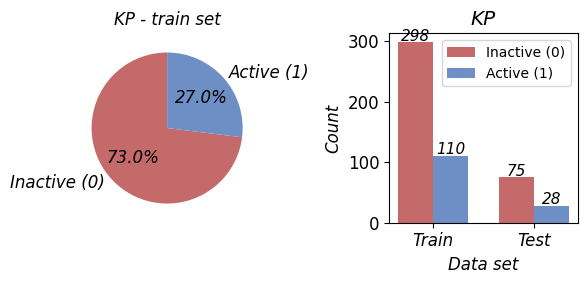

In [7]:
import matplotlib.pyplot as plt

# =========================
# KP data
# =========================
train_active = 110
train_inactive = 298

test_active = 28
test_inactive = 75

# =========================
# Style
# =========================
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 12

fig, axes = plt.subplots(
    1,
    2,
    figsize=(6,3)
)

# =========================
# Pie chart
# =========================
axes[0].pie(
    [train_inactive, train_active],
    labels=["Inactive (0)", "Active (1)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#C46A6A", "#6D8FC5"],
    textprops={
        "fontsize":12,
        "fontstyle":"italic"
    }
)

axes[0].set_title(
    "KP - train set",
    fontsize=12,
    fontstyle="italic"
)

# =========================
# Bar chart
# =========================
x = ["Train", "Test"]

inactive = [
    train_inactive,
    test_inactive
]

active = [
    train_active,
    test_active
]

width = 0.35

bars1 = axes[1].bar(
    [0-width/2,1-width/2],
    inactive,
    width,
    label="Inactive (0)",
    color="#C46A6A"
)

bars2 = axes[1].bar(
    [0+width/2,1+width/2],
    active,
    width,
    label="Active (1)",
    color="#6D8FC5"
)

axes[1].set_xticks([0,1])
axes[1].set_xticklabels(
    x,
    fontstyle="italic"
)

axes[1].set_ylabel(
    "Count",
    fontstyle="italic"
)

axes[1].set_xlabel(
    "Data set",
    fontstyle="italic"
)

axes[1].set_title(
    "KP",
    fontstyle="italic"
)

axes[1].legend(
    fontsize=10
)

for bar in list(bars1)+list(bars2):
    h = bar.get_height()
    axes[1].text(
        bar.get_x()+bar.get_width()/2,
        h+3,
        str(int(h)),
        ha="center",
        fontsize=11,
        fontstyle="italic"
    )

plt.tight_layout()

plt.savefig(
    "KP_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

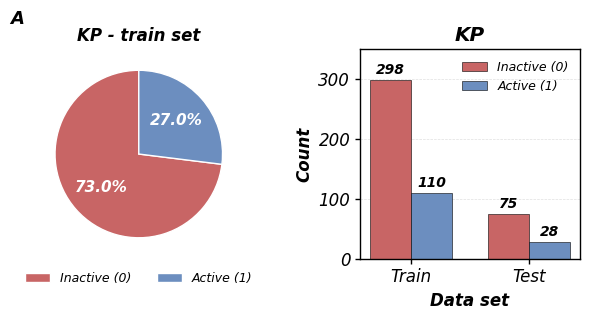

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# KP data
# =========================
train_active = 110
train_inactive = 298
test_active = 28
test_inactive = 75

# =========================
# Publication style
# =========================
plt.rcParams.update({
    "font.family": "DejaVu Sans",   # use "Helvetica" if installed
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

inactive_color = "#C86565"
active_color = "#6C8EBF"

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))

# =========================
# A. Pie chart
# =========================
wedges, texts, autotexts = axes[0].pie(
    [train_inactive, train_active],
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=[inactive_color, active_color],
    wedgeprops={"edgecolor": "white", "linewidth": 1.0},
    textprops={"fontsize": 12, "fontstyle": "italic", "fontweight": "bold"}
)

for t in autotexts:
    t.set_color("white")
    t.set_fontstyle("italic")
    t.set_fontsize(11)

axes[0].set_title(
    "KP - train set",
    fontsize=12,
    fontstyle="italic",
    fontweight="bold"
)

axes[0].legend(
    wedges,
    ["Inactive (0)", "Active (1)"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    prop={"size": 9, "style": "italic"}
)

# =========================
# B. Bar chart
# =========================
x = np.arange(2)
width = 0.35

inactive = [train_inactive, test_inactive]
active = [train_active, test_active]

bars1 = axes[1].bar(
    x - width / 2,
    inactive,
    width,
    label="Inactive (0)",
    color=inactive_color,
    edgecolor="black",
    linewidth=0.4
)

bars2 = axes[1].bar(
    x + width / 2,
    active,
    width,
    label="Active (1)",
    color=active_color,
    edgecolor="black",
    linewidth=0.4
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(["Train", "Test"], fontstyle="italic")

axes[1].set_ylabel("Count", fontstyle="italic", fontweight="bold")
axes[1].set_xlabel("Data set", fontstyle="italic", fontweight="bold")
axes[1].set_title("KP", fontstyle="italic", fontweight="bold")

axes[1].set_ylim(0, 350)
axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
axes[1].set_axisbelow(True)

axes[1].legend(
    frameon=False,
    fontsize=9,
    prop={"style": "italic", "size": 9}
)

for label in axes[1].get_yticklabels():
    label.set_fontstyle("italic")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + 5,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle="italic",
        fontweight="bold"
    )

# =========================
# Panel label
# =========================
fig.text(
    0.02, 0.95,
    "A",
    fontsize=13,
    fontweight="bold",
    fontstyle="italic"
)

plt.tight_layout(w_pad=2)

plt.savefig("KP_distribution_publication.png", dpi=600, bbox_inches="tight")
plt.savefig("KP_distribution_publication.pdf", bbox_inches="tight")
plt.show()

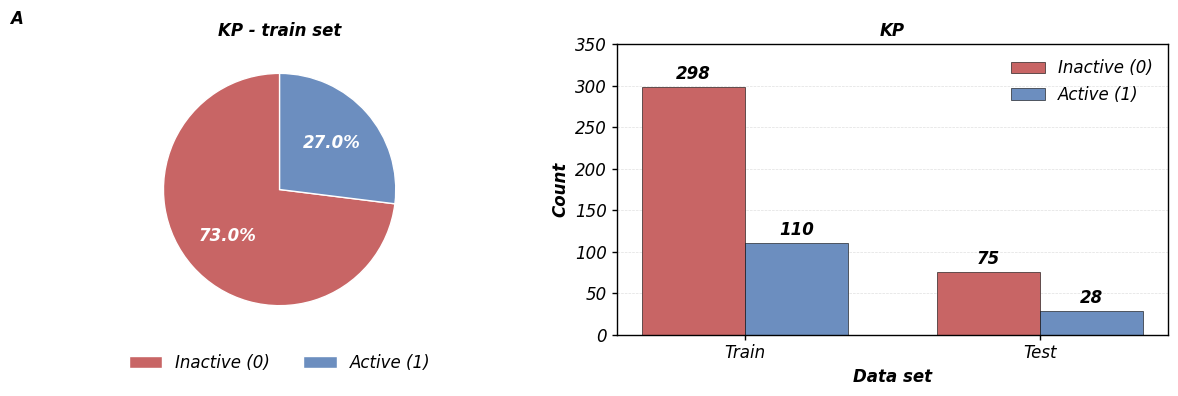

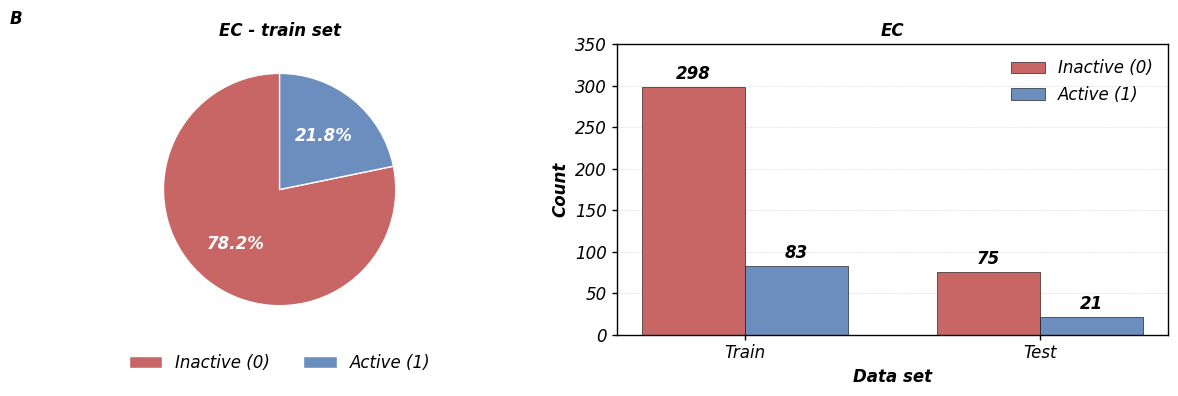

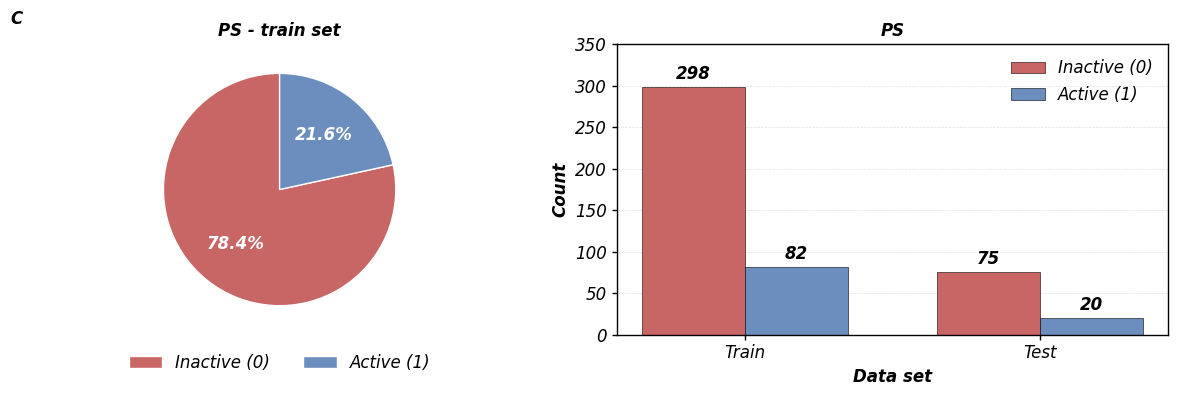

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Dataset counts
# =========================
datasets = {
    "KP": {
        "panel": "A",
        "title": "KP",
        "pie_title": "KP - train set",
        "train_active": 110,
        "train_inactive": 298,
        "test_active": 28,
        "test_inactive": 75
    },
    "EC": {
        "panel": "B",
        "title": "EC",
        "pie_title": "EC - train set",
        "train_active": 83,
        "train_inactive": 298,
        "test_active": 21,
        "test_inactive": 75
    },
    "PS": {
        "panel": "C",
        "title": "PS",
        "pie_title": "PS - train set",
        "train_active": 82,
        "train_inactive": 298,
        "test_active": 20,
        "test_inactive": 75
    }
}

# =========================
# Publication style
# =========================
plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

inactive_color = "#C86565"
active_color = "#6C8EBF"

# =========================
# Function to plot one pathogen
# =========================
def plot_distribution(name, info):
    train_active = info["train_active"]
    train_inactive = info["train_inactive"]
    test_active = info["test_active"]
    test_inactive = info["test_inactive"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    # -------------------------
    # Pie chart
    # -------------------------
    wedges, texts, autotexts = axes[0].pie(
        [train_inactive, train_active],
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=[inactive_color, active_color],
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 1.0
        },
        textprops={
            "fontsize": 12,
            "fontstyle": "italic",
            "fontweight": "bold"
        }
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontstyle("italic")
        t.set_fontsize(12)
        t.set_fontweight("bold")

    axes[0].set_title(
        info["pie_title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[0].legend(
        wedges,
        ["Inactive (0)", "Active (1)"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        prop={
            "size": 12,
            "style": "italic"
        }
    )

    # -------------------------
    # Bar chart
    # -------------------------
    x = np.arange(2)
    width = 0.35

    inactive = [train_inactive, test_inactive]
    active = [train_active, test_active]

    bars1 = axes[1].bar(
        x - width / 2,
        inactive,
        width,
        label="Inactive (0)",
        color=inactive_color,
        edgecolor="black",
        linewidth=0.4
    )

    bars2 = axes[1].bar(
        x + width / 2,
        active,
        width,
        label="Active (1)",
        color=active_color,
        edgecolor="black",
        linewidth=0.4
    )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        ["Train", "Test"],
        fontstyle="italic",
        fontsize=12
    )

    axes[1].set_ylabel(
        "Count",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_xlabel(
        "Data set",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_title(
        info["title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_ylim(0, 350)

    axes[1].grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    axes[1].set_axisbelow(True)

    axes[1].legend(
        frameon=False,
        prop={
            "style": "italic",
            "size": 12
        }
    )

    for label in axes[1].get_yticklabels():
        label.set_fontstyle("italic")
        label.set_fontsize(12)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + 5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontstyle="italic",
            fontweight="bold"
        )

    # -------------------------
    # Panel label
    # -------------------------
    fig.text(
        0.02,
        0.95,
        info["panel"],
        fontsize=12,
        fontweight="bold",
        fontstyle="italic"
    )

    plt.tight_layout(w_pad=3)

    plt.savefig(
        f"{name}_distribution_publication.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{name}_distribution_publication.pdf",
        bbox_inches="tight"
    )

    plt.show()


# =========================
# Generate 3 separate plots
# =========================
for name, info in datasets.items():
    plot_distribution(name, info)

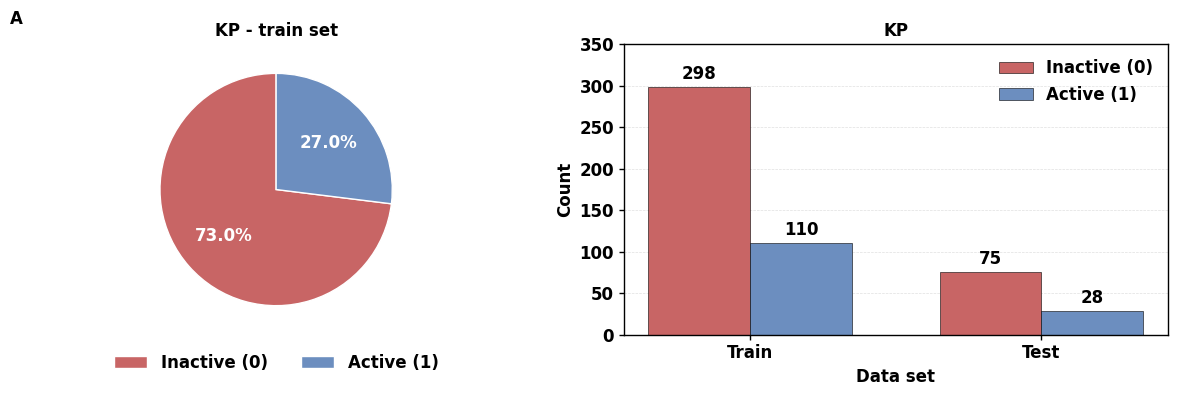

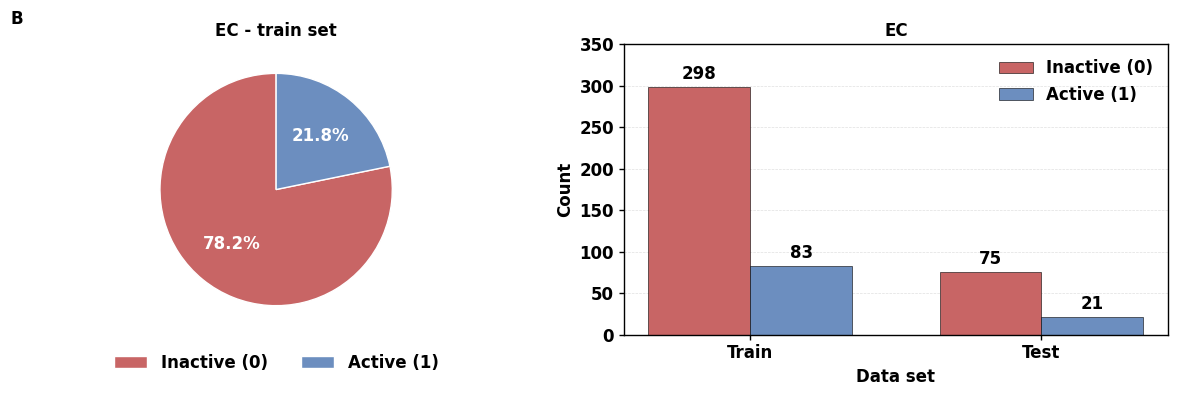

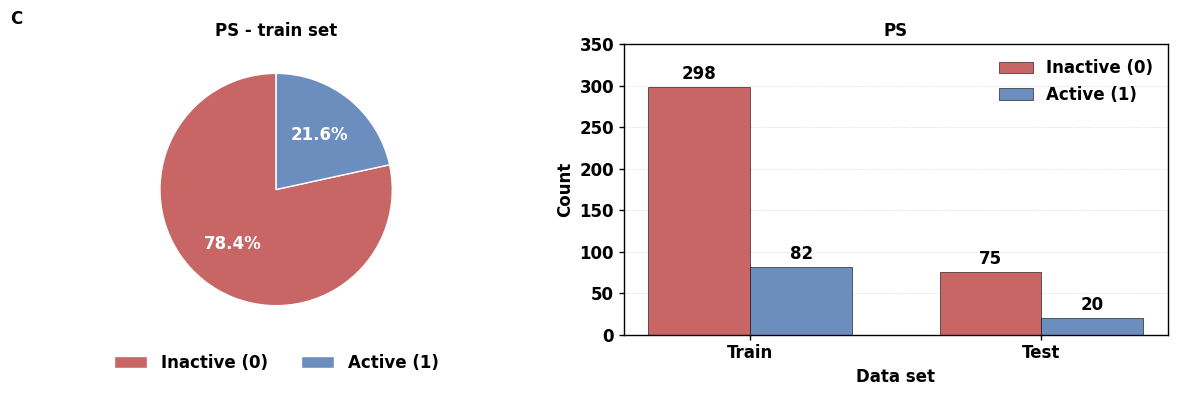

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Global publication style
# =========================
plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

inactive_color = "#C86565"
active_color = "#6C8EBF"

# =========================
# Data
# =========================
datasets = {
    "KP": {
        "panel": "A",
        "pie_title": "KP - train set",
        "bar_title": "KP",
        "train_inactive": 298,
        "train_active": 110,
        "test_inactive": 75,
        "test_active": 28
    },
    "EC": {
        "panel": "B",
        "pie_title": "EC - train set",
        "bar_title": "EC",
        "train_inactive": 298,
        "train_active": 83,
        "test_inactive": 75,
        "test_active": 21
    },
    "PS": {
        "panel": "C",
        "pie_title": "PS - train set",
        "bar_title": "PS",
        "train_inactive": 298,
        "train_active": 82,
        "test_inactive": 75,
        "test_active": 20
    }
}

# =========================
# Plot function
# =========================
def plot_one_dataset(name, d):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # -------------------------
    # Pie chart
    # -------------------------
    wedges, texts, autotexts = axes[0].pie(
        [d["train_inactive"], d["train_active"]],
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=[inactive_color, active_color],
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 1.0
        },
        textprops={
            "fontsize": 12,
            "fontfamily": "Helvetica",
            "fontweight": "bold"
        }
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontsize(12)
        t.set_fontweight("bold")
        t.set_fontfamily("Helvetica")

    axes[0].set_title(
        d["pie_title"],
        fontsize=12,
        fontweight="bold",
        fontfamily="Helvetica"
    )

    axes[0].legend(
        wedges,
        ["Inactive (0)", "Active (1)"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        prop={
            "family": "Helvetica",
            "size": 12,
            "weight": "bold"
        }
    )

    # -------------------------
    # Bar chart
    # -------------------------
    x = np.arange(2)
    width = 0.35

    inactive = [d["train_inactive"], d["test_inactive"]]
    active = [d["train_active"], d["test_active"]]

    bars1 = axes[1].bar(
        x - width / 2,
        inactive,
        width,
        label="Inactive (0)",
        color=inactive_color,
        edgecolor="black",
        linewidth=0.4
    )

    bars2 = axes[1].bar(
        x + width / 2,
        active,
        width,
        label="Active (1)",
        color=active_color,
        edgecolor="black",
        linewidth=0.4
    )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        ["Train", "Test"],
        fontfamily="Helvetica",
        fontweight="bold"
    )

    axes[1].set_ylabel(
        "Count",
        fontsize=12,
        fontweight="bold",
        fontfamily="Helvetica"
    )

    axes[1].set_xlabel(
        "Data set",
        fontsize=12,
        fontweight="bold",
        fontfamily="Helvetica"
    )

    axes[1].set_title(
        d["bar_title"],
        fontsize=12,
        fontweight="bold",
        fontfamily="Helvetica"
    )

    axes[1].set_ylim(0, 350)
    axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    axes[1].set_axisbelow(True)

    axes[1].legend(
        frameon=False,
        prop={
            "family": "Helvetica",
            "size": 12,
            "weight": "bold"
        }
    )

    for label in axes[1].get_yticklabels():
        label.set_fontfamily("Helvetica")
        label.set_fontsize(12)
        label.set_fontweight("bold")

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + 5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            fontfamily="Helvetica"
        )

    # -------------------------
    # Panel label A/B/C
    # -------------------------
    fig.text(
        0.02,
        0.95,
        d["panel"],
        fontsize=12,
        fontweight="bold",
        fontfamily="Helvetica"
    )

    plt.tight_layout(w_pad=3)

    plt.savefig(f"{name}_distribution_publication.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{name}_distribution_publication.pdf", bbox_inches="tight")
    plt.show()

# =========================
# Generate figures one by one
# =========================
plot_one_dataset("KP", datasets["KP"])
plot_one_dataset("EC", datasets["EC"])
plot_one_dataset("PS", datasets["PS"])

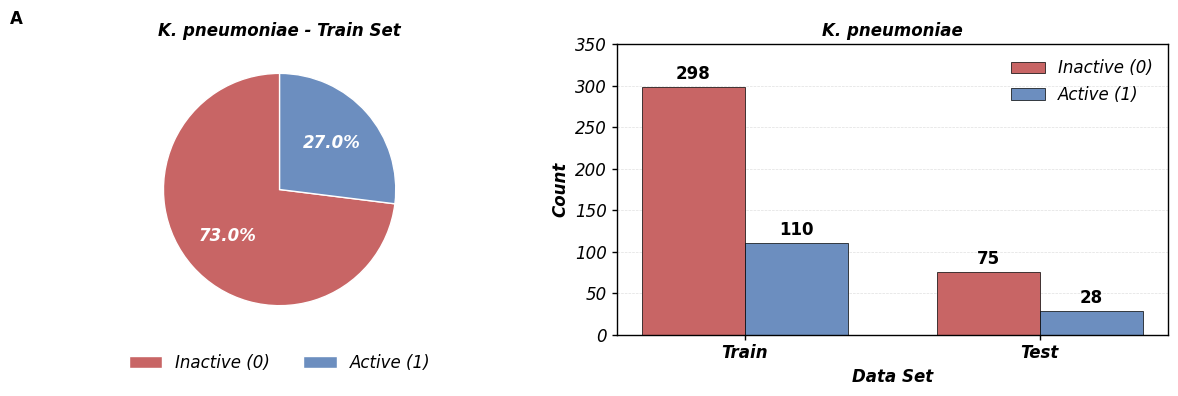

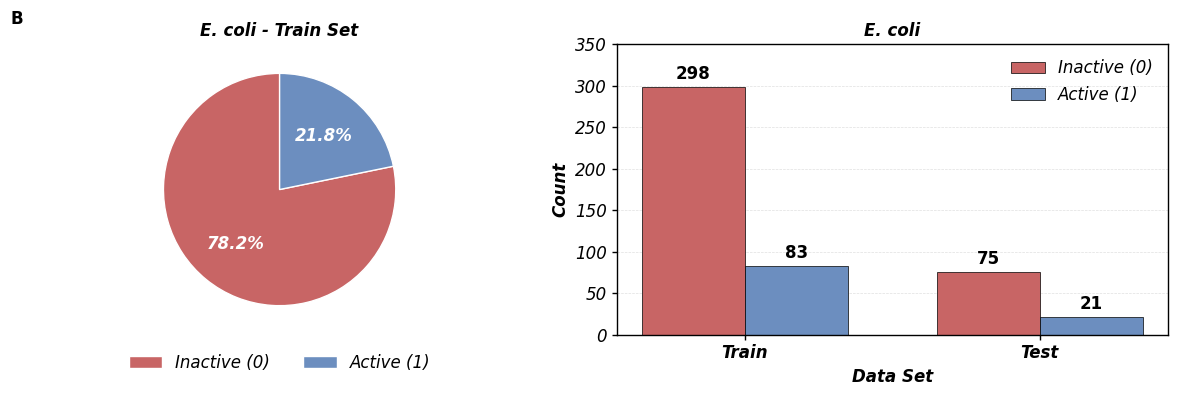

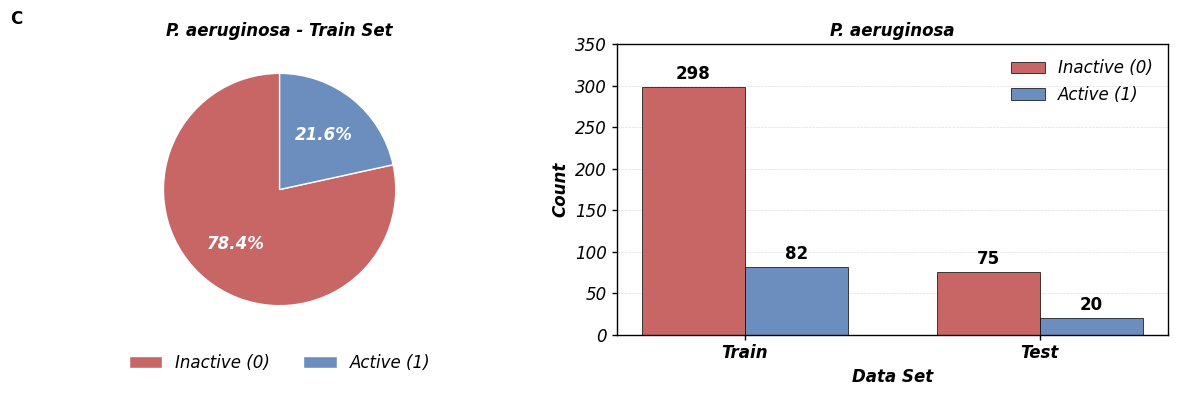

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================
# Publication Style
# =====================================
plt.rcParams.update({
    "font.family": "Helvetica",      # Change to DejaVu Sans if Helvetica unavailable
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# =====================================
# Colors
# =====================================
inactive_color = "#C86565"
active_color = "#6C8EBF"

# =====================================
# Dataset Information
# =====================================
datasets = {
    "KP": {
        "panel": "A",
        "pie_title": "K. pneumoniae - Train Set",
        "bar_title": "K. pneumoniae",
        "train_inactive": 298,
        "train_active": 110,
        "test_inactive": 75,
        "test_active": 28
    },

    "EC": {
        "panel": "B",
        "pie_title": "E. coli - Train Set",
        "bar_title": "E. coli",
        "train_inactive": 298,
        "train_active": 83,
        "test_inactive": 75,
        "test_active": 21
    },

    "PS": {
        "panel": "C",
        "pie_title": "P. aeruginosa - Train Set",
        "bar_title": "P. aeruginosa",
        "train_inactive": 298,
        "train_active": 82,
        "test_inactive": 75,
        "test_active": 20
    }
}

# =====================================
# Plot Function
# =====================================
def plot_distribution(name, d):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,4)
    )

    # =================================
    # Pie Chart
    # =================================
    wedges, texts, autotexts = axes[0].pie(
        [d["train_inactive"], d["train_active"]],
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=[inactive_color, active_color],
        wedgeprops={
            "edgecolor":"white",
            "linewidth":1
        },
        textprops={
            "fontsize":12,
            "fontstyle":"italic"
        }
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontsize(12)
        t.set_fontweight("bold")

    axes[0].set_title(
        d["pie_title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[0].legend(
        wedges,
        ["Inactive (0)", "Active (1)"],
        loc="lower center",
        bbox_to_anchor=(0.5,-0.18),
        ncol=2,
        frameon=False,
        prop={
            "size":12,
            "style":"italic"
        }
    )

    # =================================
    # Bar Chart
    # =================================
    x = np.arange(2)
    width = 0.35

    inactive = [
        d["train_inactive"],
        d["test_inactive"]
    ]

    active = [
        d["train_active"],
        d["test_active"]
    ]

    bars1 = axes[1].bar(
        x - width/2,
        inactive,
        width,
        label="Inactive (0)",
        color=inactive_color,
        edgecolor="black",
        linewidth=0.5
    )

    bars2 = axes[1].bar(
        x + width/2,
        active,
        width,
        label="Active (1)",
        color=active_color,
        edgecolor="black",
        linewidth=0.5
    )

    axes[1].set_xticks(x)

    axes[1].set_xticklabels(
        ["Train", "Test"],
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_ylabel(
        "Count",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_xlabel(
        "Data Set",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_title(
        d["bar_title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_ylim(0,350)

    axes[1].grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    axes[1].set_axisbelow(True)

    axes[1].legend(
        frameon=False,
        prop={
            "size":12,
            "style":"italic"
        }
    )

    # Italic y tick labels
    for label in axes[1].get_yticklabels():
        label.set_fontstyle("italic")

    # Value labels
    for bar in list(bars1) + list(bars2):

        h = bar.get_height()

        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            h + 5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    # =================================
    # Panel Label (A, B, C)
    # =================================
    fig.text(
        0.02,
        0.95,
        d["panel"],
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout(w_pad=3)

    plt.savefig(
        f"{name}_distribution_publication.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{name}_distribution_publication.pdf",
        bbox_inches="tight"
    )

    plt.show()

# =====================================
# Generate Figures
# =====================================
plot_distribution("KP", datasets["KP"])
plot_distribution("EC", datasets["EC"])
plot_distribution("PS", datasets["PS"])

Inactive total = 363

KP
Train inactive: 290
Train active: 90
Test inactive: 73
Test active: 23
Total: 476


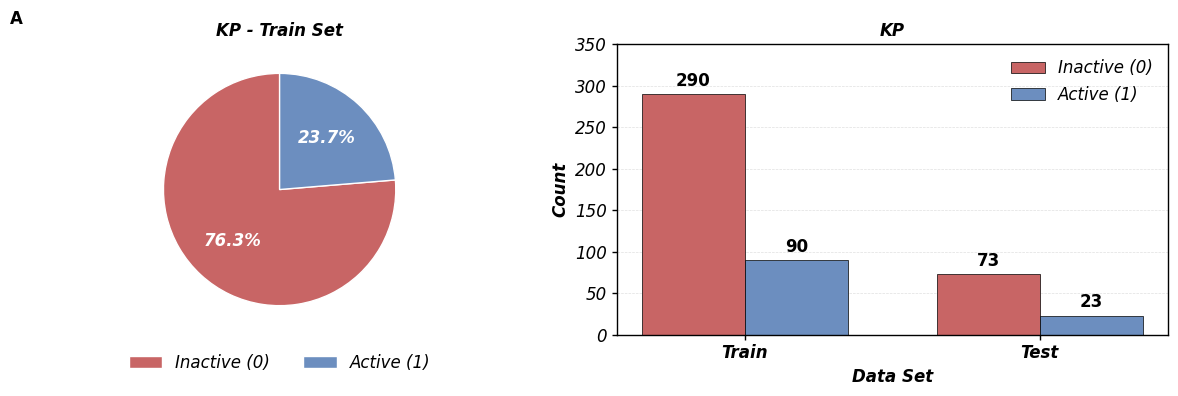


EC
Train inactive: 290
Train active: 78
Test inactive: 73
Test active: 20
Total: 461


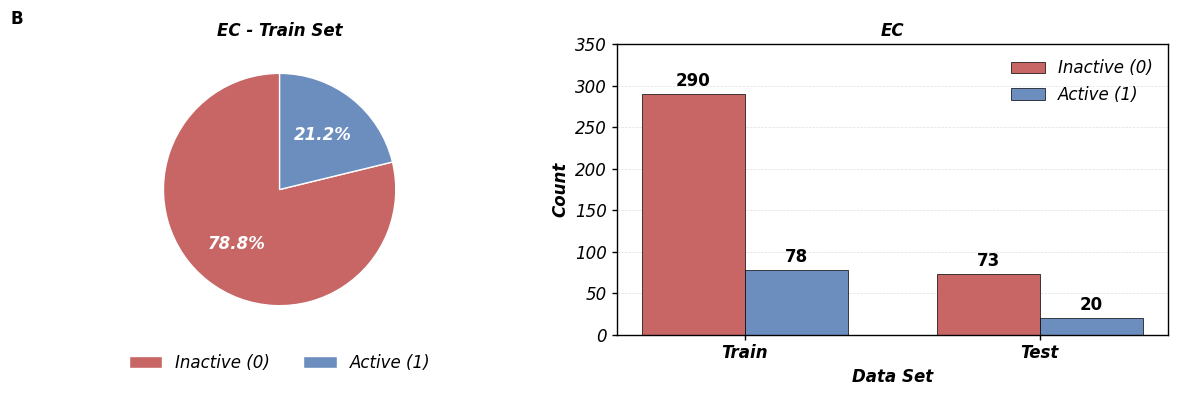


PS
Train inactive: 290
Train active: 75
Test inactive: 73
Test active: 19
Total: 457


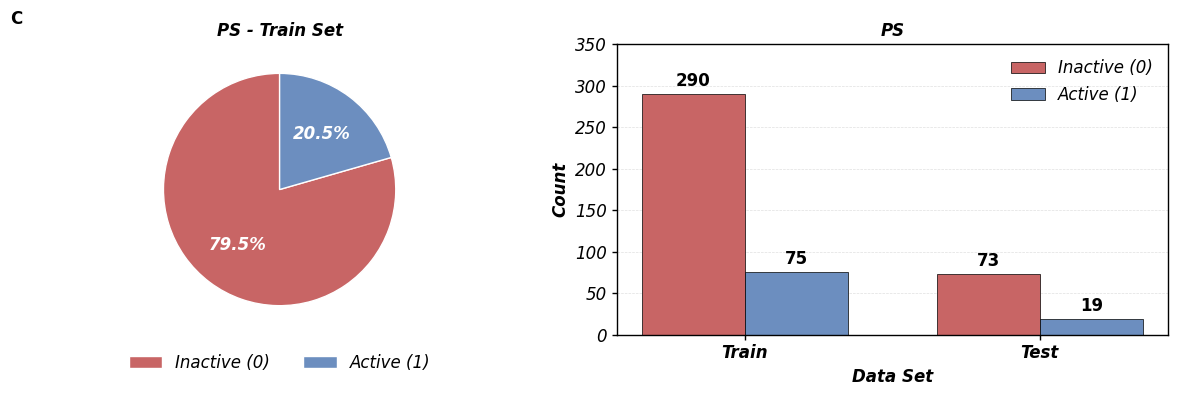

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# =========================
# File paths
# =========================
active_file = "/content/drive/MyDrive/AMP-ML/data/raw/AMP_active_raw_data_one_sheet (1).xlsx"
inactive_file = "/content/drive/MyDrive/AMP-ML/data/raw/Inactive_data_set.xlsx"

# =========================
# Load data
# =========================
active_df = pd.read_excel(active_file)
inactive_df = pd.read_excel(inactive_file)

active_df.columns = active_df.columns.str.strip()
inactive_df.columns = inactive_df.columns.str.strip()

# =========================
# Standardize columns
# =========================
active_df = active_df.rename(columns={"Activity": "Label"})
inactive_df = inactive_df.rename(columns={"Activity": "Label"})

inactive_df["Label"] = 0
active_df["Label"] = 1

# =========================
# Check inactive count
# =========================
inactive_total = len(inactive_df)

print("Inactive total =", inactive_total)

assert inactive_total == 363, f"Inactive count is {inactive_total}, not 363"

# =========================
# Normalize pathogen names
# =========================
def normalize_pathogen(x):
    x = str(x).strip().lower()

    if "kp" in x or "pneumoniae" in x:
        return "KP"
    elif "ec" in x or "coli" in x:
        return "EC"
    elif "ps" in x or "aeruginosa" in x:
        return "PS"
    else:
        return x.upper()

active_df["Pathogen_clean"] = active_df["Pathogen"].apply(normalize_pathogen)

# =========================
# Publication style
# =========================
plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

inactive_color = "#C86565"
active_color = "#6C8EBF"

# =========================
# Plot function
# =========================
def plot_one_pathogen(pathogen_code, panel_label, pathogen_title):

    active_subset = active_df[active_df["Pathogen_clean"] == pathogen_code].copy()

    pathogen_df = pd.concat(
        [
            active_subset[["Sequence", "Label"]],
            inactive_df[["Sequence", "Label"]]
        ],
        ignore_index=True
    )

    train_df, test_df = train_test_split(
        pathogen_df,
        test_size=0.2,
        stratify=pathogen_df["Label"],
        random_state=42
    )

    train_counts = train_df["Label"].value_counts()
    test_counts = test_df["Label"].value_counts()

    train_inactive = train_counts.get(0, 0)
    train_active = train_counts.get(1, 0)
    test_inactive = test_counts.get(0, 0)
    test_active = test_counts.get(1, 0)

    print(f"\n{pathogen_code}")
    print("Train inactive:", train_inactive)
    print("Train active:", train_active)
    print("Test inactive:", test_inactive)
    print("Test active:", test_active)
    print("Total:", len(pathogen_df))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # =========================
    # Pie chart
    # =========================
    wedges, texts, autotexts = axes[0].pie(
        [train_inactive, train_active],
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=[inactive_color, active_color],
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 12, "fontstyle": "italic"}
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontsize(12)
        t.set_fontweight("bold")

    axes[0].set_title(
        f"{pathogen_title} - Train Set",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[0].legend(
        wedges,
        ["Inactive (0)", "Active (1)"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        prop={"size": 12, "style": "italic"}
    )

    # =========================
    # Bar chart
    # =========================
    x = np.arange(2)
    width = 0.35

    bars1 = axes[1].bar(
        x - width / 2,
        [train_inactive, test_inactive],
        width,
        label="Inactive (0)",
        color=inactive_color,
        edgecolor="black",
        linewidth=0.5
    )

    bars2 = axes[1].bar(
        x + width / 2,
        [train_active, test_active],
        width,
        label="Active (1)",
        color=active_color,
        edgecolor="black",
        linewidth=0.5
    )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        ["Train", "Test"],
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_ylabel("Count", fontstyle="italic", fontweight="bold")
    axes[1].set_xlabel("Data Set", fontstyle="italic", fontweight="bold")
    axes[1].set_title(pathogen_title, fontstyle="italic", fontweight="bold")

    axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    axes[1].set_axisbelow(True)

    axes[1].legend(
        frameon=False,
        prop={"size": 12, "style": "italic"}
    )

    for label in axes[1].get_yticklabels():
        label.set_fontstyle("italic")

    max_y = max(train_inactive, train_active, test_inactive, test_active)
    axes[1].set_ylim(0, max_y + 60)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + 5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    # Panel label
    fig.text(
        0.02,
        0.95,
        panel_label,
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout(w_pad=3)

    plt.savefig(f"Figure2{panel_label}_{pathogen_code}_distribution.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"Figure2{panel_label}_{pathogen_code}_distribution.pdf", bbox_inches="tight")

    plt.show()

# =========================
# Plot one by one
# =========================
plot_one_pathogen("KP", "A", "KP")
plot_one_pathogen("EC", "B", "EC")
plot_one_pathogen("PS", "C", "PS")

In [17]:
# Define placeholder values for panel_label and pathogen_code
# (These are examples; for full functionality across all datasets,
# this saving logic should be inside the `plot_one_pathogen` function in cell Eo3yMZA9VdPH)
panel_label = "A"  # Example: use 'A' for the first pathogen
pathogen_code = "KP" # Example: use 'KP' for Klebsiella pneumoniae

# High-resolution PNG
plt.savefig(
    f"Figure2{panel_label}_{pathogen_code}_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

# PDF (vector format)
plt.savefig(
    f"Figure2{panel_label}_{pathogen_code}_distribution.pdf",
    bbox_inches="tight"
)

# SVG (vector format, journal-friendly)
plt.savefig(
    f"Figure2{panel_label}_{pathogen_code}_distribution.svg",
    format="svg",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [18]:
plt.savefig(f"Figure2{panel_label}_{pathogen_code}_distribution.png",
            dpi=600,
            bbox_inches="tight")

plt.savefig(f"Figure2{panel_label}_{pathogen_code}_distribution.pdf",
            bbox_inches="tight")

plt.savefig(f"Figure2{panel_label}_{pathogen_code}_distribution.svg",
            format="svg",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Inactive total = 363

KP
Train inactive: 290
Train active: 90
Test inactive: 73
Test active: 23
Total: 476


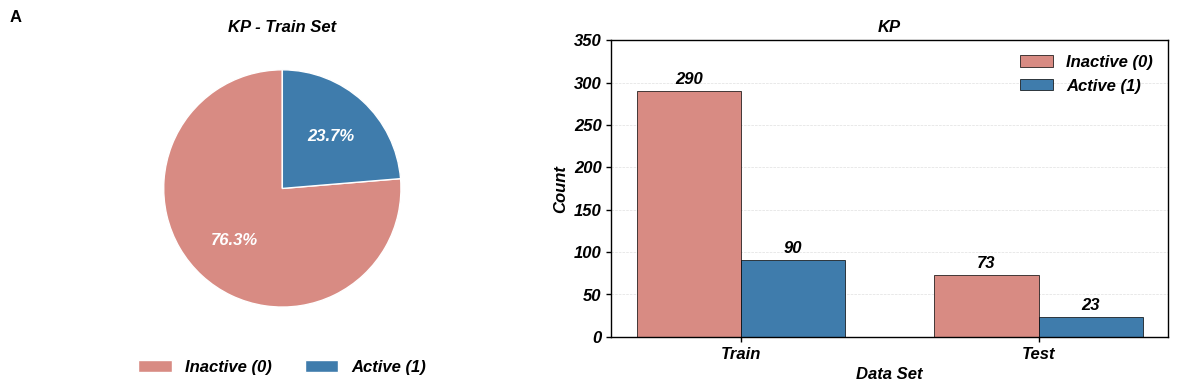


EC
Train inactive: 290
Train active: 78
Test inactive: 73
Test active: 20
Total: 461


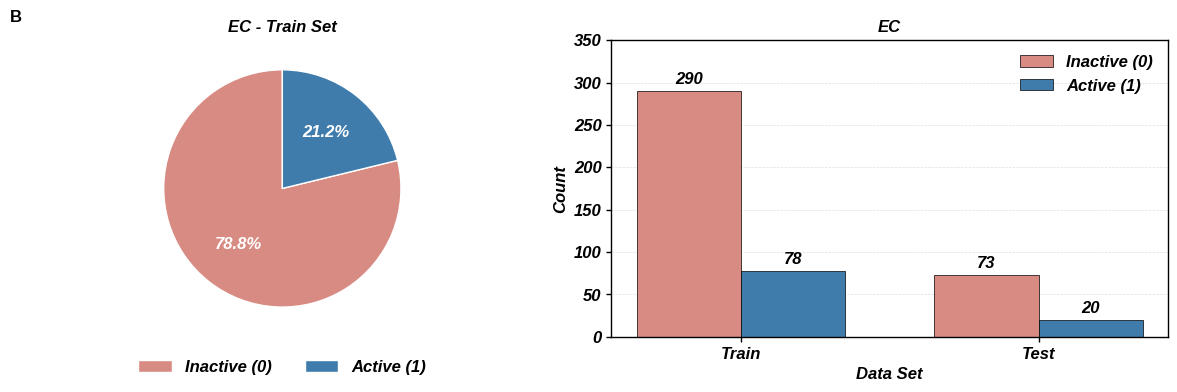


PS
Train inactive: 290
Train active: 75
Test inactive: 73
Test active: 19
Total: 457


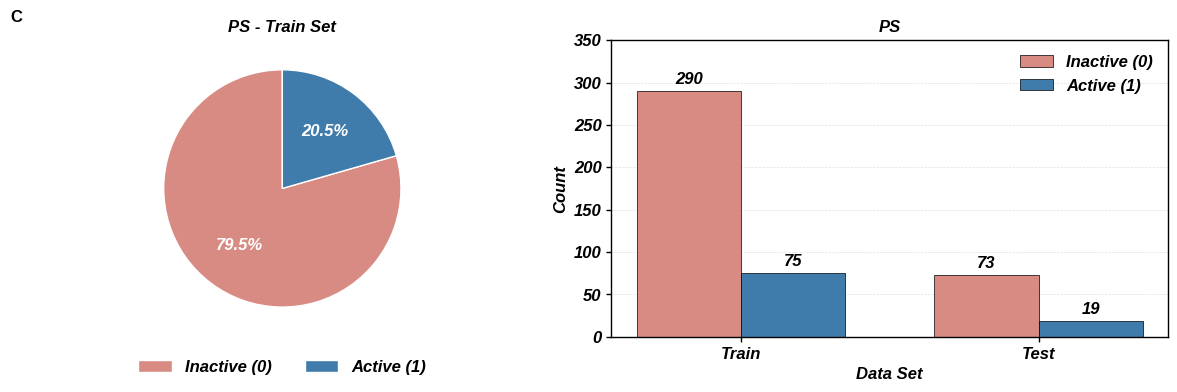

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# =========================
# File paths
# =========================
active_file = "/content/drive/MyDrive/AMP-ML/data/raw/AMP_active_raw_data_one_sheet (1).xlsx"
inactive_file = "/content/drive/MyDrive/AMP-ML/data/raw/Inactive_data_set.xlsx"

# =========================
# Load data
# =========================
active_df = pd.read_excel(active_file)
inactive_df = pd.read_excel(inactive_file)

active_df.columns = active_df.columns.str.strip()
inactive_df.columns = inactive_df.columns.str.strip()

# =========================
# Standardize columns
# =========================
active_df = active_df.rename(columns={"Activity": "Label"})
inactive_df = inactive_df.rename(columns={"Activity": "Label"})

active_df["Label"] = 1
inactive_df["Label"] = 0

# =========================
# Check inactive count
# =========================
inactive_total = len(inactive_df)
print("Inactive total =", inactive_total)

assert inactive_total == 363, f"Inactive count is {inactive_total}, not 363"

# =========================
# Normalize pathogen names
# =========================
def normalize_pathogen(x):
    x = str(x).strip().lower()

    if "kp" in x or "pneumoniae" in x:
        return "KP"
    elif "ec" in x or "coli" in x:
        return "EC"
    elif "ps" in x or "aeruginosa" in x:
        return "PS"
    else:
        return x.upper()

active_df["Pathogen_clean"] = active_df["Pathogen"].apply(normalize_pathogen)

# =========================
# Publication style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# Match amino-acid composition figure colors
active_color = "#3F7CAC"      # blue
inactive_color = "#D88B83"    # salmon

# =========================
# Plot function
# =========================
def plot_one_pathogen(pathogen_code, panel_label, pathogen_title):

    active_subset = active_df[active_df["Pathogen_clean"] == pathogen_code].copy()

    pathogen_df = pd.concat(
        [
            active_subset[["Sequence", "Label"]],
            inactive_df[["Sequence", "Label"]]
        ],
        ignore_index=True
    )

    train_df, test_df = train_test_split(
        pathogen_df,
        test_size=0.2,
        stratify=pathogen_df["Label"],
        random_state=42
    )

    train_counts = train_df["Label"].value_counts()
    test_counts = test_df["Label"].value_counts()

    train_inactive = train_counts.get(0, 0)
    train_active = train_counts.get(1, 0)
    test_inactive = test_counts.get(0, 0)
    test_active = test_counts.get(1, 0)

    print(f"\n{pathogen_code}")
    print("Train inactive:", train_inactive)
    print("Train active:", train_active)
    print("Test inactive:", test_inactive)
    print("Test active:", test_active)
    print("Total:", len(pathogen_df))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # =========================
    # Pie chart
    # =========================
    wedges, texts, autotexts = axes[0].pie(
        [train_inactive, train_active],
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=[inactive_color, active_color],
        wedgeprops={"edgecolor": "white", "linewidth": 1.0},
        textprops={"fontsize": 12, "fontstyle": "italic", "fontweight": "bold"}
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontsize(12)
        t.set_fontstyle("italic")
        t.set_fontweight("bold")

    axes[0].set_title(
        f"{pathogen_title} - Train Set",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[0].legend(
        wedges,
        ["Inactive (0)", "Active (1)"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        prop={
            "size": 12,
            "style": "italic",
            "weight": "bold"
        }
    )

    # =========================
    # Bar chart
    # =========================
    x = np.arange(2)
    width = 0.35

    bars1 = axes[1].bar(
        x - width / 2,
        [train_inactive, test_inactive],
        width,
        label="Inactive (0)",
        color=inactive_color,
        edgecolor="black",
        linewidth=0.5
    )

    bars2 = axes[1].bar(
        x + width / 2,
        [train_active, test_active],
        width,
        label="Active (1)",
        color=active_color,
        edgecolor="black",
        linewidth=0.5
    )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        ["Train", "Test"],
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_ylabel(
        "Count",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_xlabel(
        "Data Set",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_title(
        pathogen_title,
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )
    axes[1].set_axisbelow(True)

    axes[1].legend(
        frameon=False,
        prop={
            "size": 12,
            "style": "italic",
            "weight": "bold"
        }
    )

    for label in axes[1].get_yticklabels():
        label.set_fontstyle("italic")
        label.set_fontweight("bold")

    max_y = max(train_inactive, train_active, test_inactive, test_active)
    axes[1].set_ylim(0, max_y + 60)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + 5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontstyle="italic",
            fontweight="bold"
        )

    # =========================
    # Panel label
    # =========================
    fig.text(
        0.02,
        0.95,
        panel_label,
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout(w_pad=3)

    # =========================
    # Save files
    # =========================
    plt.savefig(
        f"Figure2{panel_label}_{pathogen_code}_distribution.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        f"Figure2{panel_label}_{pathogen_code}_distribution.pdf",
        bbox_inches="tight"
    )

    plt.savefig(
        f"Figure2{panel_label}_{pathogen_code}_distribution.svg",
        format="svg",
        bbox_inches="tight"
    )

    plt.show()

# =========================
# Generate figures one by one
# =========================
plot_one_pathogen("KP", "A", "KP")
plot_one_pathogen("EC", "B", "EC")
plot_one_pathogen("PS", "C", "PS")

Inactive total = 363

KP
Train inactive: 290
Train active: 90
Test inactive: 73
Test active: 23
Total: 476


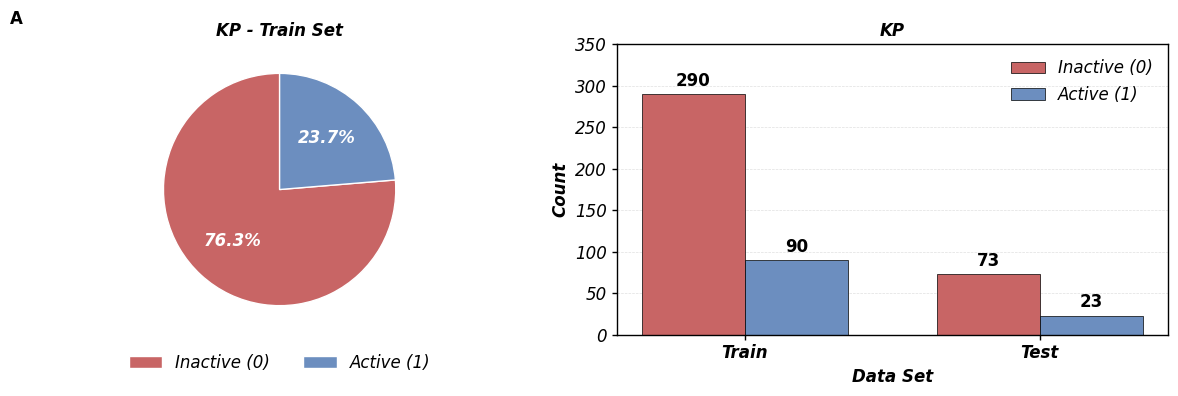


EC
Train inactive: 290
Train active: 78
Test inactive: 73
Test active: 20
Total: 461


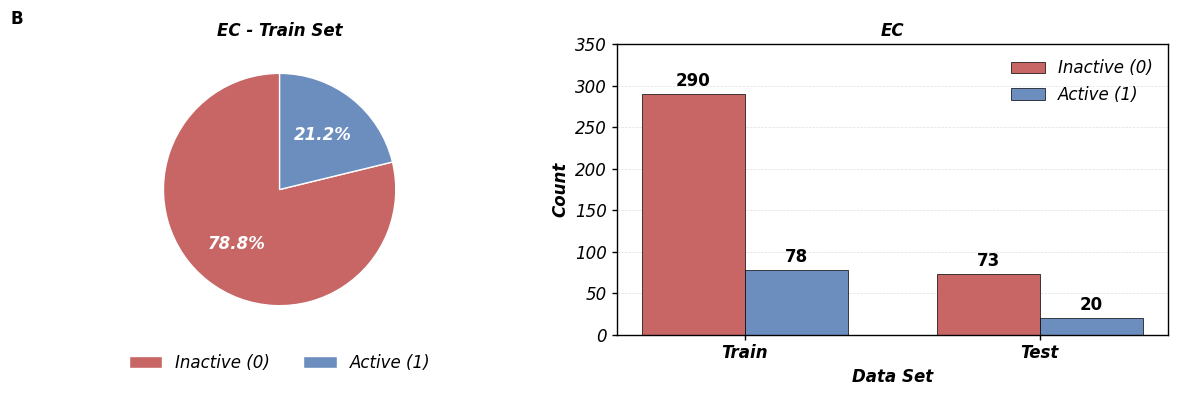


PS
Train inactive: 290
Train active: 75
Test inactive: 73
Test active: 19
Total: 457


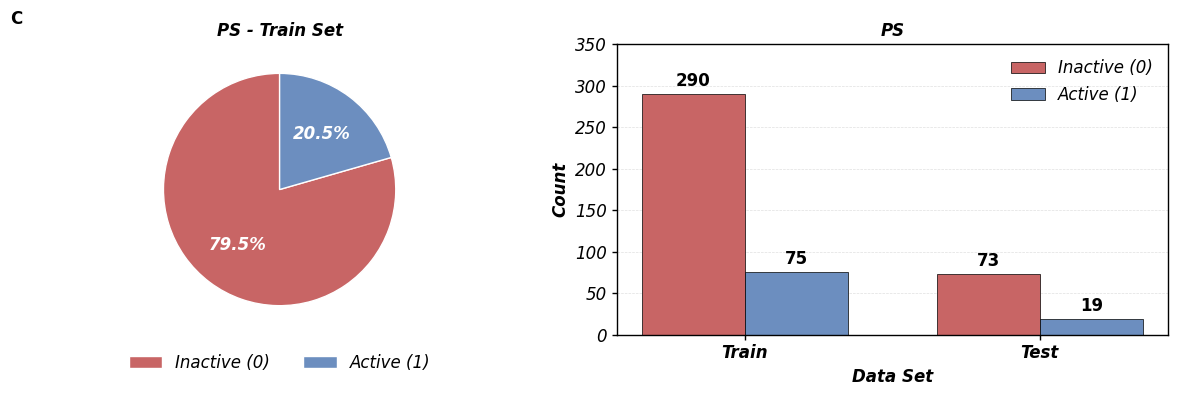

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# =========================
# File paths
# =========================
active_file = "/content/drive/MyDrive/AMP-ML/data/raw/AMP_active_raw_data_one_sheet (1).xlsx"
inactive_file = "/content/drive/MyDrive/AMP-ML/data/raw/Inactive_data_set.xlsx"

# =========================
# Load data
# =========================
active_df = pd.read_excel(active_file)
inactive_df = pd.read_excel(inactive_file)

active_df.columns = active_df.columns.str.strip()
inactive_df.columns = inactive_df.columns.str.strip()

# =========================
# Standardize columns
# =========================
active_df = active_df.rename(columns={"Activity": "Label"})
inactive_df = inactive_df.rename(columns={"Activity": "Label"})

active_df["Label"] = 1
inactive_df["Label"] = 0

# =========================
# Check inactive count
# =========================
inactive_total = len(inactive_df)
print("Inactive total =", inactive_total)

assert inactive_total == 363, f"Inactive count is {inactive_total}, not 363"

# =========================
# Normalize pathogen names
# =========================
def normalize_pathogen(x):
    x = str(x).strip().lower()

    if "kp" in x or "pneumoniae" in x:
        return "KP"
    elif "ec" in x or "coli" in x:
        return "EC"
    elif "ps" in x or "aeruginosa" in x:
        return "PS"
    else:
        return x.upper()

active_df["Pathogen_clean"] = active_df["Pathogen"].apply(normalize_pathogen)

# =========================
# Publication style
# =========================
plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

inactive_color = "#C86565"
active_color = "#6C8EBF"

# =========================
# Plot function
# =========================
def plot_one_pathogen(pathogen_code, panel_label, pathogen_title):

    active_subset = active_df[active_df["Pathogen_clean"] == pathogen_code].copy()

    pathogen_df = pd.concat(
        [
            active_subset[["Sequence", "Label"]],
            inactive_df[["Sequence", "Label"]]
        ],
        ignore_index=True
    )

    train_df, test_df = train_test_split(
        pathogen_df,
        test_size=0.2,
        stratify=pathogen_df["Label"],
        random_state=42
    )

    train_counts = train_df["Label"].value_counts()
    test_counts = test_df["Label"].value_counts()

    train_inactive = train_counts.get(0, 0)
    train_active = train_counts.get(1, 0)
    test_inactive = test_counts.get(0, 0)
    test_active = test_counts.get(1, 0)

    print(f"\n{pathogen_code}")
    print("Train inactive:", train_inactive)
    print("Train active:", train_active)
    print("Test inactive:", test_inactive)
    print("Test active:", test_active)
    print("Total:", len(pathogen_df))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # =========================
    # Pie chart
    # =========================
    wedges, texts, autotexts = axes[0].pie(
        [train_inactive, train_active],
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=[inactive_color, active_color],
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 12, "fontstyle": "italic"}
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontsize(12)
        t.set_fontweight("bold")

    axes[0].set_title(
        f"{pathogen_title} - Train Set",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    axes[0].legend(
        wedges,
        ["Inactive (0)", "Active (1)"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        prop={"size": 12, "style": "italic"}
    )

    # =========================
    # Bar chart
    # =========================
    x = np.arange(2)
    width = 0.35

    bars1 = axes[1].bar(
        x - width / 2,
        [train_inactive, test_inactive],
        width,
        label="Inactive (0)",
        color=inactive_color,
        edgecolor="black",
        linewidth=0.5
    )

    bars2 = axes[1].bar(
        x + width / 2,
        [train_active, test_active],
        width,
        label="Active (1)",
        color=active_color,
        edgecolor="black",
        linewidth=0.5
    )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        ["Train", "Test"],
        fontstyle="italic",
        fontweight="bold"
    )

    axes[1].set_ylabel("Count", fontstyle="italic", fontweight="bold")
    axes[1].set_xlabel("Data Set", fontstyle="italic", fontweight="bold")
    axes[1].set_title(pathogen_title, fontstyle="italic", fontweight="bold")

    axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    axes[1].set_axisbelow(True)

    axes[1].legend(
        frameon=False,
        prop={"size": 12, "style": "italic"}
    )

    for label in axes[1].get_yticklabels():
        label.set_fontstyle("italic")

    max_y = max(train_inactive, train_active, test_inactive, test_active)
    axes[1].set_ylim(0, max_y + 60)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + 5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    # =========================
    # Panel label
    # =========================
    fig.text(
        0.02,
        0.95,
        panel_label,
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout(w_pad=3)

    # =========================
    # Save files
    # =========================
    plt.savefig(
        f"Figure2{panel_label}_{pathogen_code}_distribution.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        f"Figure2{panel_label}_{pathogen_code}_distribution.pdf",
        bbox_inches="tight"
    )

    plt.savefig(
        f"Figure2{panel_label}_{pathogen_code}_distribution.svg",
        format="svg",
        bbox_inches="tight"
    )

    plt.show()

# =========================
# Generate figures one by one
# =========================
plot_one_pathogen("KP", "A", "KP")
plot_one_pathogen("EC", "B", "EC")
plot_one_pathogen("PS", "C", "PS")

In [20]:
# ============================================================
# CD-HIT-2D for KP, EC, PS using active + inactive raw data
# ============================================================

!apt-get update -qq
!apt-get install -y cd-hit
!pip install -q biopython pandas openpyxl scikit-learn

import os
import subprocess
import pandas as pd
from Bio import SeqIO
from sklearn.model_selection import train_test_split

# ============================================================
# 1. File paths
# ============================================================

active_file = "/content/drive/MyDrive/AMP-ML/data/raw/AMP_active_raw_data_one_sheet (1).xlsx"
inactive_file = "/content/drive/MyDrive/AMP-ML/data/raw/Inactive_data_set.xlsx"

output_dir = "/content/CDHIT_all_results"
os.makedirs(output_dir, exist_ok=True)

seq_col = "Sequence"

thresholds = {
    90: {"c": 0.90, "n": 5},
    80: {"c": 0.80, "n": 5},
    70: {"c": 0.70, "n": 4}
}

# ============================================================
# 2. Load data
# ============================================================

active_df = pd.read_excel(active_file)
inactive_df = pd.read_excel(inactive_file)

active_df.columns = active_df.columns.str.strip()
inactive_df.columns = inactive_df.columns.str.strip()

active_df = active_df.rename(columns={"Activity": "Label"})
inactive_df = inactive_df.rename(columns={"Activity": "Label"})

active_df["Label"] = 1
inactive_df["Label"] = 0

print("Active total:", len(active_df))
print("Inactive total:", len(inactive_df))

assert len(inactive_df) == 363, f"Inactive count is {len(inactive_df)}, not 363"

# ============================================================
# 3. Clean sequence column
# ============================================================

def clean_sequences(df):
    df = df.copy()
    df[seq_col] = (
        df[seq_col]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "", regex=False)
    )
    df = df.dropna(subset=[seq_col])
    df = df.drop_duplicates(subset=[seq_col]).reset_index(drop=True)
    return df

active_df = clean_sequences(active_df)
inactive_df = clean_sequences(inactive_df)

print("Clean active:", len(active_df))
print("Clean inactive:", len(inactive_df))

# ============================================================
# 4. Normalize pathogen names
# ============================================================

def normalize_pathogen(x):
    x = str(x).strip().lower()

    if "kp" in x or "pneumoniae" in x:
        return "KP"
    elif "ec" in x or "coli" in x:
        return "EC"
    elif "ps" in x or "aeruginosa" in x:
        return "PS"
    else:
        return x.upper()

active_df["Pathogen_clean"] = active_df["Pathogen"].apply(normalize_pathogen)

print(active_df["Pathogen_clean"].value_counts())

# ============================================================
# 5. Helper: save FASTA
# ============================================================

def save_fasta(df, fasta_path, prefix):
    with open(fasta_path, "w") as f:
        for i, seq in enumerate(df[seq_col]):
            f.write(f">{prefix}_{i}\n{seq}\n")

# ============================================================
# 6. Prepare train/test files for each pathogen
# ============================================================

datasets = {}

for pathogen in ["KP", "EC", "PS"]:

    active_subset = active_df[active_df["Pathogen_clean"] == pathogen].copy()

    pathogen_df = pd.concat(
        [
            active_subset[[seq_col, "Label"]],
            inactive_df[[seq_col, "Label"]]
        ],
        ignore_index=True
    )

    pathogen_df = clean_sequences(pathogen_df)

    train_df, test_df = train_test_split(
        pathogen_df,
        test_size=0.2,
        stratify=pathogen_df["Label"],
        random_state=42
    )

    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    train_csv = os.path.join(output_dir, f"{pathogen}_train.csv")
    test_csv = os.path.join(output_dir, f"{pathogen}_test.csv")

    train_fasta = os.path.join(output_dir, f"{pathogen}_train.fasta")
    test_fasta = os.path.join(output_dir, f"{pathogen}_test.fasta")

    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)

    save_fasta(train_df, train_fasta, "train")
    save_fasta(test_df, test_fasta, "test")

    datasets[pathogen] = {
        "train_df": train_df,
        "test_df": test_df,
        "train_fasta": train_fasta,
        "test_fasta": test_fasta
    }

    print(f"\n{pathogen}")
    print("Train:", train_df["Label"].value_counts().to_dict())
    print("Test:", test_df["Label"].value_counts().to_dict())
    print("Total:", len(pathogen_df))

# ============================================================
# 7. Run CD-HIT-2D
# ============================================================

summary_records = []

for pathogen, data in datasets.items():

    train_fasta = data["train_fasta"]
    test_fasta = data["test_fasta"]
    test_df = data["test_df"]
    test_count = len(test_df)

    all_test_ids = {f"test_{i}" for i in range(test_count)}

    for threshold, params in thresholds.items():

        output_prefix = os.path.join(
            output_dir,
            f"{pathogen}_CDHIT_{threshold}"
        )

        cmd = [
            "cd-hit-2d",
            "-i", train_fasta,
            "-i2", test_fasta,
            "-o", output_prefix,
            "-c", str(params["c"]),
            "-n", str(params["n"]),
            "-d", "0",
            "-M", "16000",
            "-T", "2"
        ]

        print("\n" + "=" * 70)
        print(f"Running {pathogen} CD-HIT-2D at {threshold}%")
        print(" ".join(cmd))
        print("=" * 70)

        subprocess.run(cmd, check=True)

        independent_ids = set(
            record.id for record in SeqIO.parse(output_prefix, "fasta")
        )

        similar_ids = all_test_ids - independent_ids

        similar_indices = sorted(
            [int(x.replace("test_", "")) for x in similar_ids]
        )

        independent_indices = sorted(
            [int(x.replace("test_", "")) for x in independent_ids]
        )

        similar_df = test_df.iloc[similar_indices].copy()
        independent_df = test_df.iloc[independent_indices].copy()

        similar_df["CDHIT_threshold"] = threshold
        similar_df["CDHIT_result"] = f"Similar_to_train_>={threshold}%"

        independent_df["CDHIT_threshold"] = threshold
        independent_df["CDHIT_result"] = f"Independent_<{threshold}%"

        similar_csv = os.path.join(
            output_dir,
            f"{pathogen}_test_similar_CDHIT_{threshold}.csv"
        )

        independent_csv = os.path.join(
            output_dir,
            f"{pathogen}_test_independent_CDHIT_{threshold}.csv"
        )

        similar_df.to_csv(similar_csv, index=False)
        independent_df.to_csv(independent_csv, index=False)

        summary_records.append({
            "Pathogen": pathogen,
            "Threshold": threshold,
            "Training_peptides": len(data["train_df"]),
            "Test_peptides": test_count,
            "Similar_test_peptides": len(similar_df),
            "Independent_test_peptides": len(independent_df),
            "Percent_similar": round(len(similar_df) / test_count * 100, 2),
            "Percent_independent": round(len(independent_df) / test_count * 100, 2),
            "Similar_file": similar_csv,
            "Independent_file": independent_csv
        })

# ============================================================
# 8. Save summary
# ============================================================

summary_df = pd.DataFrame(summary_records)

summary_csv = os.path.join(output_dir, "CDHIT_2D_summary.csv")
summary_xlsx = os.path.join(output_dir, "CDHIT_2D_summary.xlsx")

summary_df.to_csv(summary_csv, index=False)
summary_df.to_excel(summary_xlsx, index=False)

summary_df

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cd-hit is already the newest version (4.8.1-4).
0 upgraded, 0 newly installed, 0 to remove and 43 not upgraded.
Active total: 305
Inactive total: 363
Clean active: 288
Clean inactive: 363
Pathogen_clean
KP    113
EC     95
PS     80
Name: count, dtype: int64

KP
Train: {0: 290, 1: 90}
Test: {0: 73, 1: 23}
Total: 476

EC
Train: {0: 290, 1: 76}
Test: {0: 73, 1: 19}
Total: 458

PS
Train: {0: 290, 1: 64}
Test: {0: 73, 1: 16}
Total: 443

Running KP CD-HIT-2D at 90%
cd-hit-2d -i /content/CDHIT_all_results/KP_train.fasta -i2 /content/CDHIT_all_results/KP_test.fasta -o /content/CDHIT_all_results/KP_CDHIT_90 -c 0.9 -n 5 -d 0 -M 16000 -T 2

Running KP CD-HIT-2D at 80%
cd-hit-2d -i /content/CDHIT_all_results/KP_trai

,Pathogen,Threshold,Training_peptides,Test_peptides,Similar_test_peptides,Independent_test_peptides,Percent_similar,Percent_independent,Similar_file,Independent_file
0,KP,90,380,96,23,73,23.96,76.04,/content/CDHIT_all_results/KP_test_similar_CDH...,/content/CDHIT_all_results/KP_test_independent...
1,KP,80,380,96,27,69,28.12,71.88,/content/CDHIT_all_results/KP_test_similar_CDH...,/content/CDHIT_all_results/KP_test_independent...
2,KP,70,380,96,30,66,31.25,68.75,/content/CDHIT_all_results/KP_test_similar_CDH...,/content/CDHIT_all_results/KP_test_independent...
3,EC,90,366,92,18,74,19.57,80.43,/content/CDHIT_all_results/EC_test_similar_CDH...,/content/CDHIT_all_results/EC_test_independent...
4,EC,80,366,92,23,69,25.00,75.00,/content/CDHIT_all_results/EC_test_similar_CDH...,/content/CDHIT_all_results/EC_test_independent...
5,EC,70,366,92,23,69,25.00,75.00,/content/CDHIT_all_results/EC_test_similar_CDH...,/content/CDHIT_all_results/EC_test_independent...
6,PS,90,354,89,20,69,22.47,77.53,/content/CDHIT_all_results/PS_test_similar_CDH...,/content/CDHIT_all_results/PS_test_independent...
7,PS,80,354,89,21,68,23.60,76.40,/content/CDHIT_all_results/PS_test_similar_CDH...,/content/CDHIT_all_results/PS_test_independent...
8,PS,70,354,89,21,68,23.60,76.40,/content/CDHIT_all_results/PS_test_similar_CDH...,/content/CDHIT_all_results/PS_test_independent...



KP
Samples: 476
Features: 31
Activity
0    363
1    113
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


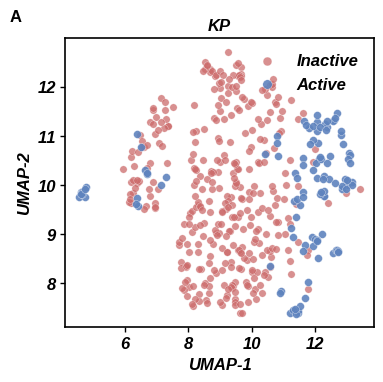


EC
Samples: 461
Features: 31
Activity
0    363
1     98
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


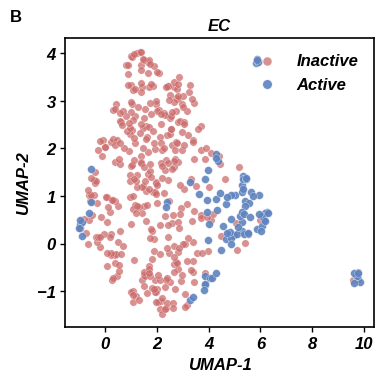


PS
Samples: 457
Features: 31
Activity
0    363
1     94
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


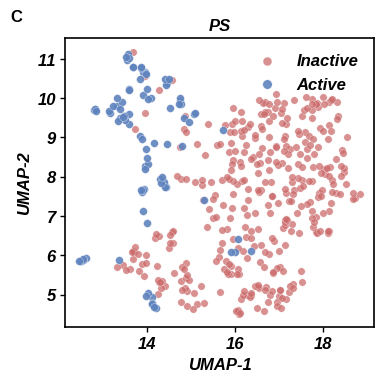

In [21]:
# ============================================
# UMAP for KP, EC, PS using X_train/X_test files
# ============================================

!pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },

    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },

    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}



# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# =========================
# Load data
# =========================
def load_xy(info):
    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# =========================
# Plot one dataset
# =========================
def plot_umap_one(pathogen):

    info = files[pathogen]
    X, y = load_xy(info)

    print(f"\n{pathogen}")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print(y.value_counts().sort_index())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.15,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    inactive = y == 0
    active = y == 1

    fig, ax = plt.subplots(figsize=(4, 4))

    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=28,
        c=inactive_color,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.25,
        label="Inactive"
    )

    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=32,
        c=active_color,
        alpha=0.90,
        edgecolors="white",
        linewidths=0.25,
        label="Active"
    )

    ax.set_title(
        info["title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_xlabel(
        "UMAP-1",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_ylabel(
        "UMAP-2",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontstyle("italic")
        label.set_fontweight("bold")
        label.set_fontsize(12)

    ax.text(
        -0.18,
        1.06,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    leg = ax.legend(
        loc="upper right",
        frameon=False,
        markerscale=1.2,
        prop={
            "size": 12,
            "style": "italic",
            "weight": "bold"
        }
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.grid(False)

    plt.tight_layout()

    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.pdf", bbox_inches="tight")
    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.svg", bbox_inches="tight")

    plt.show()

# =========================
# Generate one by one
# =========================
plot_umap_one("KP")
plot_umap_one("EC")
plot_umap_one("PS")


KP
Samples: 476
Features: 31
Activity
0    363
1    113
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


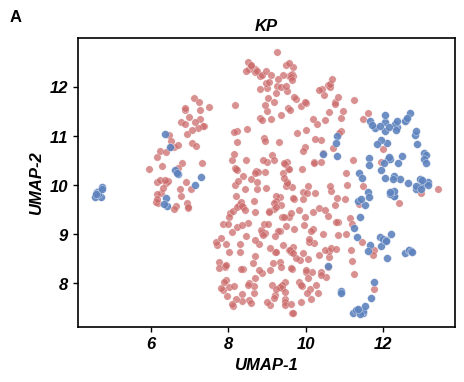


EC
Samples: 461
Features: 31
Activity
0    363
1     98
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


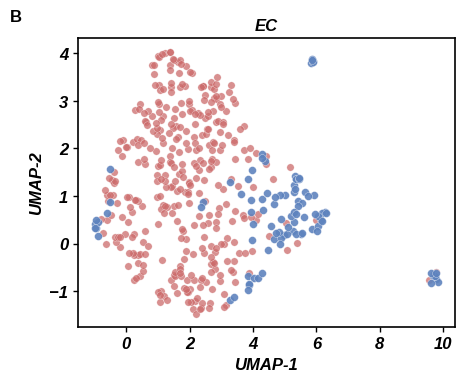


PS
Samples: 457
Features: 31
Activity
0    363
1     94
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


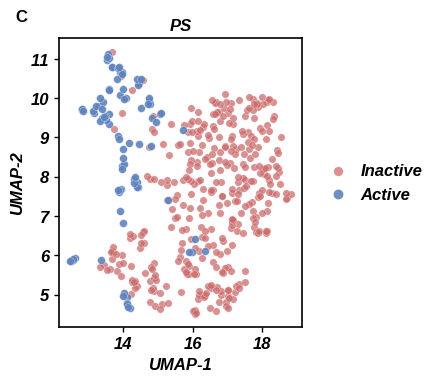

In [33]:
# ============================================
# UMAP for KP, EC, PS using X_train/X_test files
# Legend only outside PS panel
# ============================================

!pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },
    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },
    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# =========================
# Load data
# =========================
def load_xy(info):
    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# =========================
# Plot one dataset
# =========================
def plot_umap_one(pathogen):

    info = files[pathogen]
    X, y = load_xy(info)

    print(f"\n{pathogen}")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print(y.value_counts().sort_index())

    X_scaled = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.15,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    inactive = y == 0
    active = y == 1

    fig, ax = plt.subplots(figsize=(4.8, 4))

    # Inactive
    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=28,
        c=inactive_color,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.25,
        label="Inactive"
    )

    # Active
    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=32,
        c=active_color,
        alpha=0.90,
        edgecolors="white",
        linewidths=0.25,
        label="Active"
    )

    ax.set_title(
        info["title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_xlabel(
        "UMAP-1",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_ylabel(
        "UMAP-2",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontstyle("italic")
        label.set_fontweight("bold")
        label.set_fontsize(12)

    ax.text(
        -0.18,
        1.06,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    # Legend only for PS, outside the box
    if pathogen == "PS":
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            handletextpad=0.4,
            borderaxespad=0,
            markerscale=1.3,
            prop={
                "size": 12,
                "style": "italic",
                "weight": "bold"
            }
        )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.grid(False)

    plt.tight_layout()

    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.pdf", bbox_inches="tight")
    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.svg", bbox_inches="tight")

    plt.show()

# =========================
# Generate one by one
# =========================
plot_umap_one("KP")
plot_umap_one("EC")
plot_umap_one("PS")


KP
Samples: 476
Features: 31
Activity
0    363
1    113
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


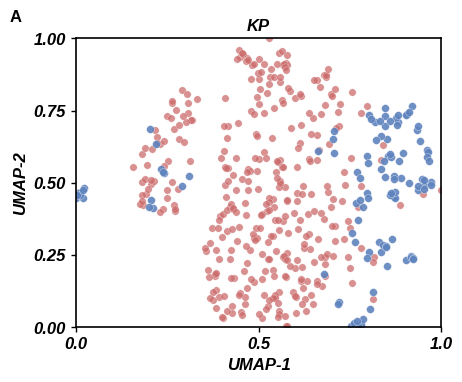


EC
Samples: 461
Features: 31
Activity
0    363
1     98
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


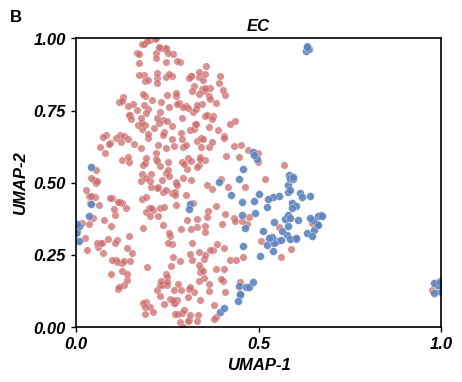


PS
Samples: 457
Features: 31
Activity
0    363
1     94
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


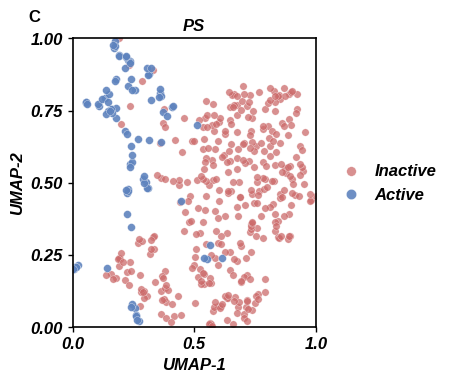

In [34]:
# ============================================
# UMAP for KP, EC, PS using X_train/X_test files
# Same 0–1 scale for all plots
# Legend only outside PS panel
# ============================================

!pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },
    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },
    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# =========================
# Load data
# =========================
def load_xy(info):
    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# =========================
# Plot one dataset
# =========================
def plot_umap_one(pathogen):

    info = files[pathogen]
    X, y = load_xy(info)

    print(f"\n{pathogen}")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print(y.value_counts().sort_index())

    X_scaled = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.15,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    # Normalize all UMAP plots to the same 0–1 scale
    emb = MinMaxScaler().fit_transform(emb)

    inactive = y == 0
    active = y == 1

    fig, ax = plt.subplots(figsize=(4.8, 4))

    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=28,
        c=inactive_color,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.25,
        label="Inactive"
    )

    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=32,
        c=active_color,
        alpha=0.90,
        edgecolors="white",
        linewidths=0.25,
        label="Active"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])

    ax.set_title(info["title"], fontsize=12, fontstyle="italic", fontweight="bold")
    ax.set_xlabel("UMAP-1", fontsize=12, fontstyle="italic", fontweight="bold")
    ax.set_ylabel("UMAP-2", fontsize=12, fontstyle="italic", fontweight="bold")

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontstyle("italic")
        label.set_fontweight("bold")
        label.set_fontsize(12)

    ax.text(
        -0.18, 1.06, info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    # Label only on PS, outside the box
    if pathogen == "PS":
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            handletextpad=0.4,
            borderaxespad=0,
            markerscale=1.3,
            prop={
                "size": 12,
                "style": "italic",
                "weight": "bold"
            }
        )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.grid(False)

    plt.tight_layout()

    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.pdf", bbox_inches="tight")
    plt.savefig(f"Figure3{info['panel']}_{pathogen}_UMAP.svg", bbox_inches="tight")

    plt.show()

# =========================
# Generate one by one
# =========================
plot_umap_one("KP")
plot_umap_one("EC")
plot_umap_one("PS")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


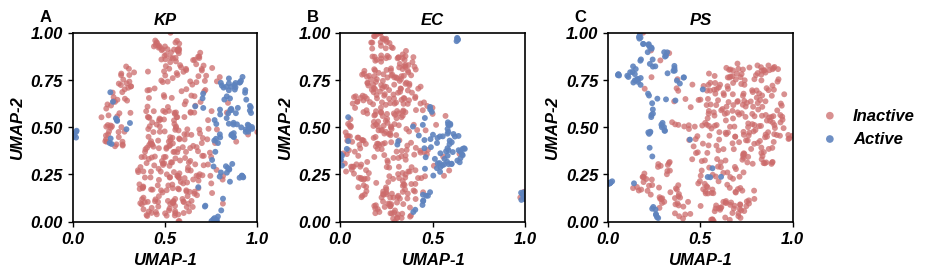

In [35]:
# ============================================
# Combined UMAP Figure (KP, EC, PS)
# Publication style
# ============================================

!pip install -q umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ============================================
# Style
# ============================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# ============================================
# Load data
# ============================================

def load_xy(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])

    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# ============================================
# Figure
# ============================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(9, 3)
)

for ax, pathogen in zip(
    axes,
    ["KP", "EC", "PS"]
):

    info = files[pathogen]

    X, y = load_xy(info)

    X_scaled = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.15,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    # same scale
    emb = MinMaxScaler().fit_transform(emb)

    inactive = y == 0
    active = y == 1

    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=18,
        c=inactive_color,
        alpha=0.75,
        edgecolors="none",
        label="Inactive"
    )

    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=18,
        c=active_color,
        alpha=0.90,
        edgecolors="none",
        label="Active"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])

    ax.set_xlabel(
        "UMAP-1",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_ylabel(
        "UMAP-2",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_title(
        pathogen,
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    for tick in ax.get_xticklabels():
        tick.set_fontstyle("italic")
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontstyle("italic")
        tick.set_fontweight("bold")

    ax.text(
        -0.18,
        1.06,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    # legend only on PS
    if pathogen == "PS":

        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.03, 0.5),
            frameon=False,
            handletextpad=0.4,
            markerscale=1.3,
            prop={
                "size":12,
                "style":"italic",
                "weight":"bold"
            }
        )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.grid(False)

# ============================================
# Layout
# ============================================

plt.subplots_adjust(
    left=0.08,
    right=0.88,
    bottom=0.22,
    top=0.85,
    wspace=0.45
)

# ============================================
# Save
# ============================================

plt.savefig(
    "Figure3_UMAP_combined.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure3_UMAP_combined.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure3_UMAP_combined.svg",
    bbox_inches="tight"
)

plt.show()


KP
Samples: 476
Features: 31
Class counts:
Activity
0    363
1    113
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



EC
Samples: 461
Features: 31
Class counts:
Activity
0    363
1     98
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



PS
Samples: 457
Features: 31
Class counts:
Activity
0    363
1     94
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


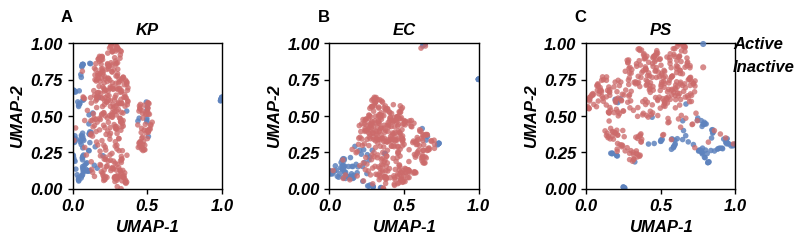

In [22]:
# ============================================
# UMAP for KP, EC, PS using X_train/X_test files
# Old Figure 3 style: one row, legend only on PS
# ============================================

!pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },

    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },

    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style: 12 pt bold italic
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# =========================
# Load data
# =========================
def load_xy(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# =========================
# Create combined Figure 3
# =========================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.5, 2.7)
)

for ax, pathogen in zip(axes, ["KP", "EC", "PS"]):

    info = files[pathogen]

    X, y = load_xy(info)

    print(f"\n{pathogen}")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print("Class counts:")
    print(y.value_counts().sort_index())

    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)

    # UMAP
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.10,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    # Normalize to 0–1 like old plot
    emb = MinMaxScaler().fit_transform(emb)

    active = y == 1
    inactive = y == 0

    # Plot Active first, then Inactive
    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=16,
        c=active_color,
        alpha=0.85,
        edgecolors="none",
        label="Active"
    )

    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=16,
        c=inactive_color,
        alpha=0.78,
        edgecolors="none",
        label="Inactive"
    )

    # Title
    ax.set_title(
        info["title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold",
        pad=6
    )

    # Axis labels
    ax.set_xlabel(
        "UMAP-1",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_ylabel(
        "UMAP-2",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    # Axis range like old plot
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])

    # Tick style
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontstyle("italic")
        label.set_fontweight("bold")
        label.set_fontsize(12)

    # Panel label
    ax.text(
        -0.08,
        1.15,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# =========================
# Legend only on PS panel
# =========================
axes[2].legend(
    loc="upper right",
    bbox_to_anchor=(1.50, 1.15),
    frameon=False,
    markerscale=1.1,
    prop={
        "size": 12,
        "style": "italic",
        "weight": "bold"
    }
)

plt.tight_layout(w_pad=2.0)

# =========================
# Save outputs
# =========================
plt.savefig("Figure3_UMAP_KP_EC_PS_old_style.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure3_UMAP_KP_EC_PS_old_style.pdf", bbox_inches="tight")
plt.savefig("Figure3_UMAP_KP_EC_PS_old_style.svg", bbox_inches="tight")

plt.show()


KP
Samples: 476
Features: 31
Class counts:
Activity
0    363
1    113
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



EC
Samples: 461
Features: 31
Class counts:
Activity
0    363
1     98
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



PS
Samples: 457
Features: 31
Class counts:
Activity
0    363
1     94
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_532/750075599.py:173: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(


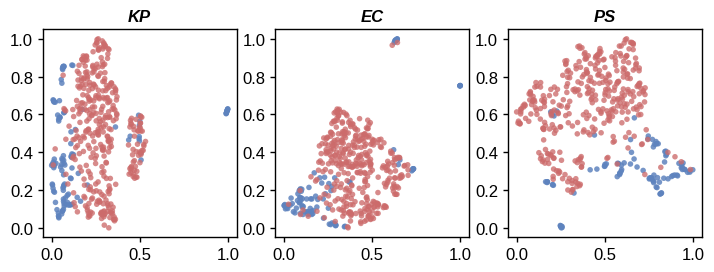

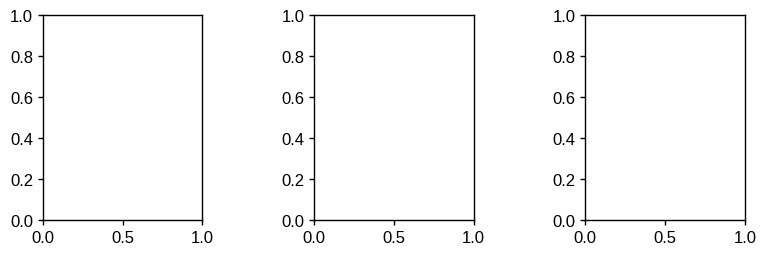

In [23]:
# ============================================
# UMAP for KP, EC, PS using X_train/X_test files
# Old Figure 3 style: one row, legend only on PS
# ============================================

!pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },

    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },

    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style: 12 pt bold italic
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# =========================
# Load data
# =========================
def load_xy(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# =========================
# Create combined Figure 3
# =========================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.5, 2.7)
)

for ax, pathogen in zip(axes, ["KP", "EC", "PS"]):

    info = files[pathogen]

    X, y = load_xy(info)

    print(f"\n{pathogen}")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print("Class counts:")
    print(y.value_counts().sort_index())

    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)

    # UMAP
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.10,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    # Normalize to 0–1 like old plot
    emb = MinMaxScaler().fit_transform(emb)

    active = y == 1
    inactive = y == 0

    # Plot Active first, then Inactive
    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=16,
        c=active_color,
        alpha=0.85,
        edgecolors="none",
        label="Active"
    )

    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=16,
        c=inactive_color,
        alpha=0.78,
        edgecolors="none",
        label="Inactive"
    )

    # Title
    ax.set_title(
        info["title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold",
        pad=6
    )


# Better figure size
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

# In scatter plots, use cleaner points
s=18
alpha=0.75

# Better legend only on PS panel
axes[2].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.02),
    frameon=False,
    markerscale=1.2,
    handletextpad=0.4,
    borderaxespad=0,
    prop={
        "size": 12,
        "style": "italic",
        "weight": "bold"
    }
)

plt.subplots_adjust(
    left=0.08,
    right=0.86,
    bottom=0.22,
    top=0.86,
    wspace=0.70
)

plt.savefig("Figure3_UMAP_publication.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure3_UMAP_publication.pdf", bbox_inches="tight")
plt.savefig("Figure3_UMAP_publication.svg", bbox_inches="tight")
plt.show()


KP
Samples: 476
Features: 31
Class counts:
Activity
0    363
1    113
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



EC
Samples: 461
Features: 31
Class counts:
Activity
0    363
1     98
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



PS
Samples: 457
Features: 31
Class counts:
Activity
0    363
1     94
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


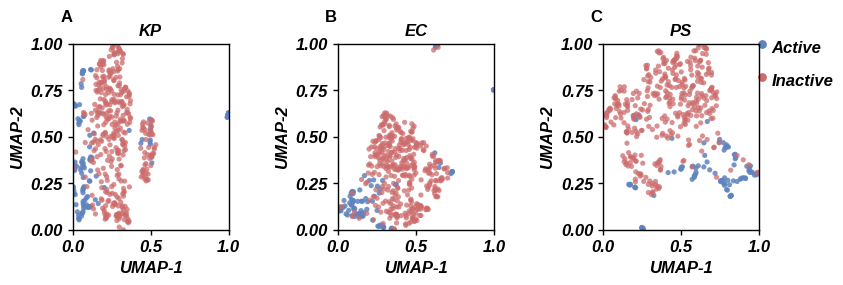

In [24]:
# ============================================
# UMAP for KP, EC, PS using X_train/X_test files
# Publication style: A-C panels, PS label only
# ============================================

!pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },

    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },

    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

active_color = "#5E83BE"
inactive_color = "#CC6B6B"

# =========================
# Load data
# =========================
def load_xy(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X, y.astype(int)

# =========================
# Create Figure 3
# =========================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.8, 3.0)
)

for ax, pathogen in zip(axes, ["KP", "EC", "PS"]):

    info = files[pathogen]
    X, y = load_xy(info)

    print(f"\n{pathogen}")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print("Class counts:")
    print(y.value_counts().sort_index())

    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)

    # UMAP
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.10,
        metric="euclidean",
        random_state=42
    )

    emb = reducer.fit_transform(X_scaled)

    # Normalize UMAP coordinates to 0–1
    emb = MinMaxScaler().fit_transform(emb)

    active = y == 1
    inactive = y == 0

    # Active first
    ax.scatter(
        emb[active, 0],
        emb[active, 1],
        s=14,
        c=active_color,
        alpha=0.85,
        edgecolors="none"
    )

    # Inactive second
    ax.scatter(
        emb[inactive, 0],
        emb[inactive, 1],
        s=14,
        c=inactive_color,
        alpha=0.75,
        edgecolors="none"
    )

    ax.set_title(
        info["title"],
        fontsize=12,
        fontstyle="italic",
        fontweight="bold",
        pad=6
    )

    ax.set_xlabel(
        "UMAP-1",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_ylabel(
        "UMAP-2",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontstyle("italic")
        tick.set_fontweight("bold")
        tick.set_fontsize(12)

    ax.text(
        -0.08,
        1.12,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# =========================
# Active / Inactive label only on PS
# =========================
ps_ax = axes[2]

ps_ax.scatter(
    [1.02],
    [1.00],
    transform=ps_ax.transAxes,
    s=28,
    color=active_color,
    clip_on=False
)

ps_ax.text(
    1.08,
    0.98,
    "Active",
    transform=ps_ax.transAxes,
    fontsize=12,
    fontstyle="italic",
    fontweight="bold",
    va="center"
)

ps_ax.scatter(
    [1.02],
    [0.82],
    transform=ps_ax.transAxes,
    s=28,
    color=inactive_color,
    clip_on=False
)

ps_ax.text(
    1.08,
    0.80,
    "Inactive",
    transform=ps_ax.transAxes,
    fontsize=12,
    fontstyle="italic",
    fontweight="bold",
    va="center"
)

# =========================
# Layout and save
# =========================
plt.subplots_adjust(
    left=0.08,
    right=0.86,
    bottom=0.22,
    top=0.84,
    wspace=0.70
)

plt.savefig("Figure3_UMAP_publication.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure3_UMAP_publication.pdf", bbox_inches="tight")
plt.savefig("Figure3_UMAP_publication.svg", bbox_inches="tight")

plt.show()

In [25]:
# =========================
# Active / Inactive label only on PS
# =========================
ps_ax = axes[2]

# Active marker
ps_ax.scatter(
    [1.06],
    [1.00],
    transform=ps_ax.transAxes,
    s=30,
    color=active_color,
    clip_on=False
)

ps_ax.text(
    1.15,
    0.98,
    "Active",
    transform=ps_ax.transAxes,
    fontsize=12,
    fontstyle="italic",
    fontweight="bold",
    va="center"
)

# Inactive marker
ps_ax.scatter(
    [1.06],
    [0.82],
    transform=ps_ax.transAxes,
    s=30,
    color=inactive_color,
    clip_on=False
)

ps_ax.text(
    1.15,
    0.80,
    "Inactive",
    transform=ps_ax.transAxes,
    fontsize=12,
    fontstyle="italic",
    fontweight="bold",
    va="center"
)

Text(1.15, 0.8, 'Inactive')


KP
Active samples: 113
Features: 31
Network nodes: 31
Network edges: 108

EC
Active samples: 98
Features: 31
Network nodes: 31
Network edges: 105

PS
Active samples: 94
Features: 31
Network nodes: 31
Network edges: 154


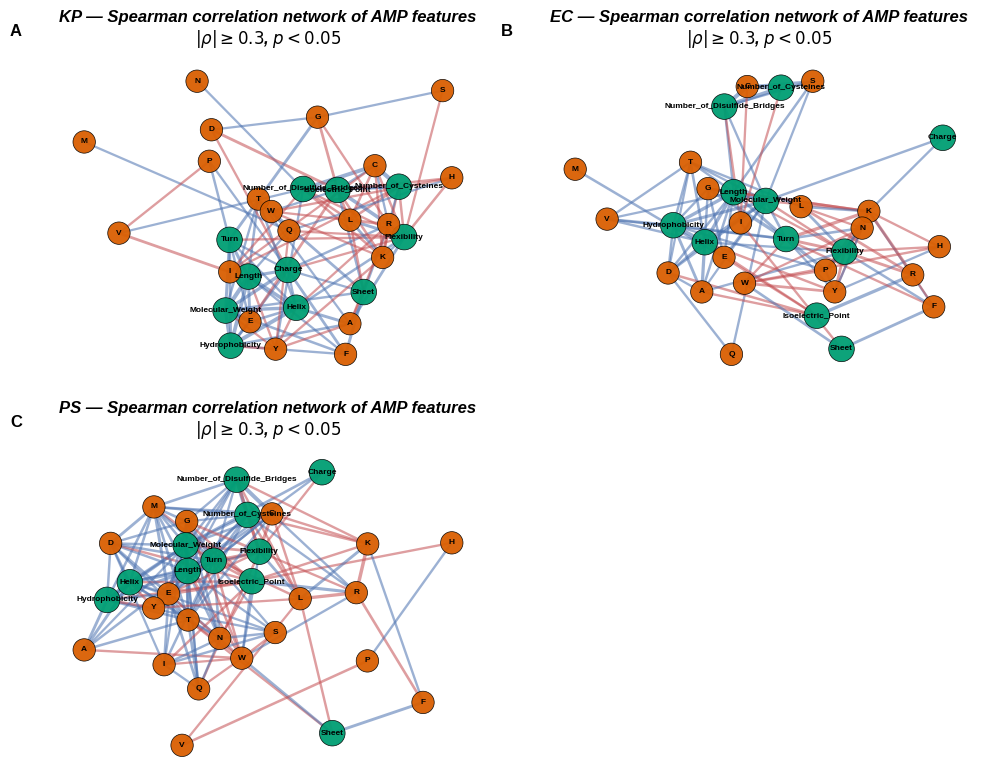

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },
    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },
    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# =========================
# Helper: load active feature matrix
# =========================
def load_active_features(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    # active only
    X_active = X[y.astype(int) == 1].copy()

    return X_active

# =========================
# Helper: plot network
# =========================
def plot_corr_network(ax, X_active, title, panel):

    corr, pvals = spearmanr(X_active)

    corr = pd.DataFrame(
        corr,
        index=X_active.columns,
        columns=X_active.columns
    )

    pvals = pd.DataFrame(
        pvals,
        index=X_active.columns,
        columns=X_active.columns
    )

    # Threshold
    rho_cutoff = 0.30
    p_cutoff = 0.05

    G = nx.Graph()

    for feature in X_active.columns:
        G.add_node(feature)

    for i, f1 in enumerate(X_active.columns):
        for j, f2 in enumerate(X_active.columns):
            if j <= i:
                continue

            rho = corr.loc[f1, f2]
            p = pvals.loc[f1, f2]

            if abs(rho) >= rho_cutoff and p < p_cutoff:
                G.add_edge(
                    f1,
                    f2,
                    weight=abs(rho),
                    rho=rho
                )

    # Node groups
    aa_features = list("ACDEFGHIKLMNPQRSTVWY")

    node_colors = []
    node_sizes = []

    for node in G.nodes():
        if node in aa_features:
            node_colors.append("#D95F02")   # orange for AA composition
            node_sizes.append(260)
        else:
            node_colors.append("#009E73")   # green for physicochemical descriptors
            node_sizes.append(340)

    # Edge colors
    edge_colors = []
    edge_widths = []

    for u, v, d in G.edges(data=True):
        if d["rho"] > 0:
            edge_colors.append("#4C72B0")   # blue positive
        else:
            edge_colors.append("#C44E52")   # red negative

        edge_widths.append(1.0 + 2.0 * d["weight"])

    pos = nx.spring_layout(
        G,
        seed=42,
        k=0.75
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=0.55
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.95
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=6,
        font_weight="bold"
    )

    ax.set_title(
        f"{title} — Spearman correlation network of AMP features\n"
        r"$|\rho| \geq 0.3$, $p < 0.05$",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold"
    )

    ax.text(
        -0.08,
        1.05,
        panel,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

    print(f"\n{title}")
    print("Active samples:", X_active.shape[0])
    print("Features:", X_active.shape[1])
    print("Network nodes:", G.number_of_nodes())
    print("Network edges:", G.number_of_edges())

# =========================
# Plot Figure 7
# =========================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8)
)

axes = axes.flatten()

# KP
X_kp = load_active_features(files["KP"])
plot_corr_network(
    axes[0],
    X_kp,
    files["KP"]["title"],
    files["KP"]["panel"]
)

# EC
X_ec = load_active_features(files["EC"])
plot_corr_network(
    axes[1],
    X_ec,
    files["EC"]["title"],
    files["EC"]["panel"]
)

# PS
X_ps = load_active_features(files["PS"])
plot_corr_network(
    axes[2],
    X_ps,
    files["PS"]["title"],
    files["PS"]["panel"]
)

# Empty fourth panel
axes[3].axis("off")

plt.tight_layout()

plt.savefig(
    "Figure7_Spearman_network_active_AMPs.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure7_Spearman_network_active_AMPs.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure7_Spearman_network_active_AMPs.svg",
    bbox_inches="tight"
)

plt.show()

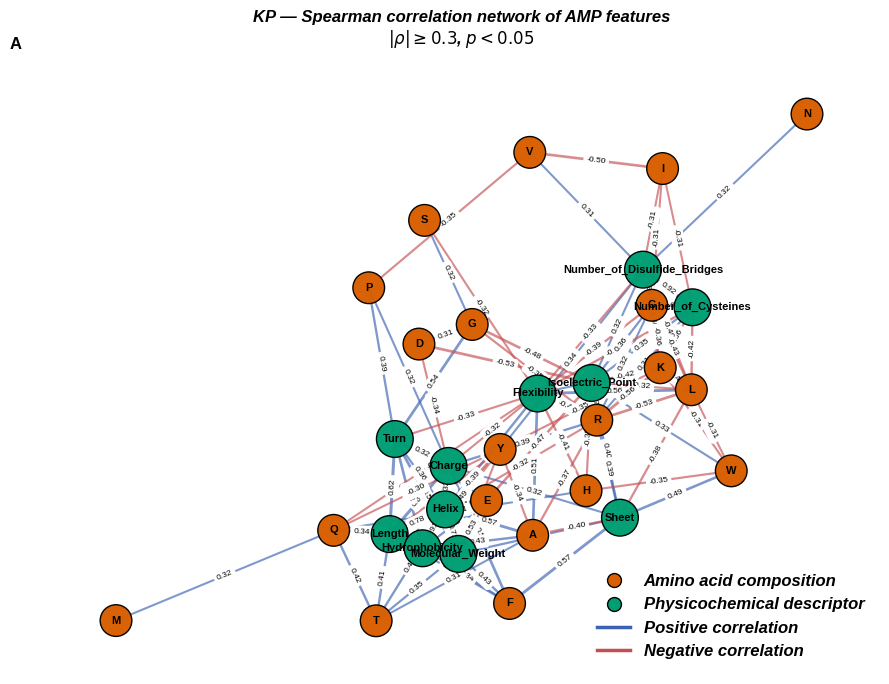


KP
Active samples: 113
Features: 31
Nodes: 31
Edges: 108


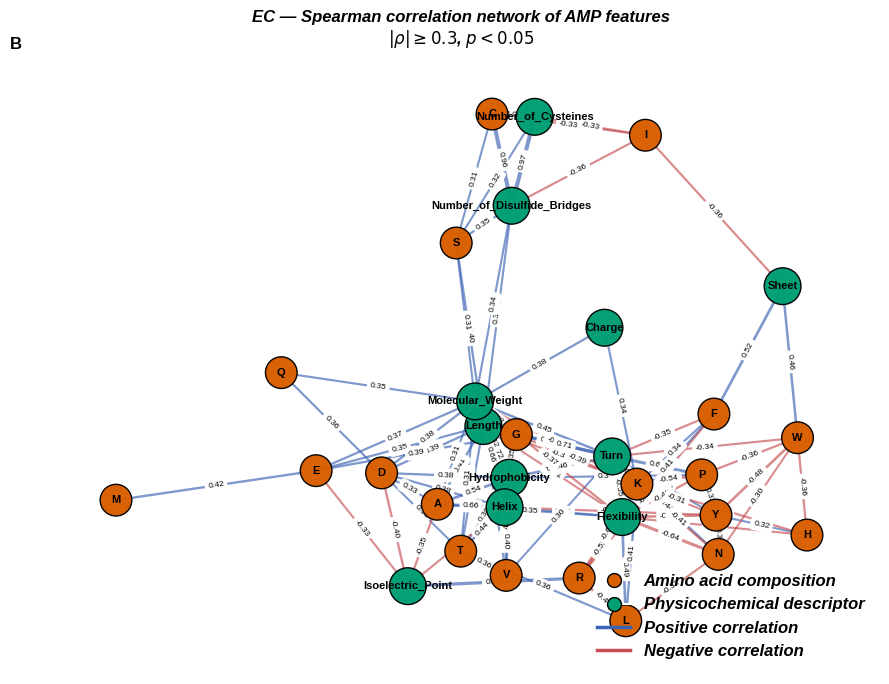


EC
Active samples: 98
Features: 31
Nodes: 31
Edges: 105


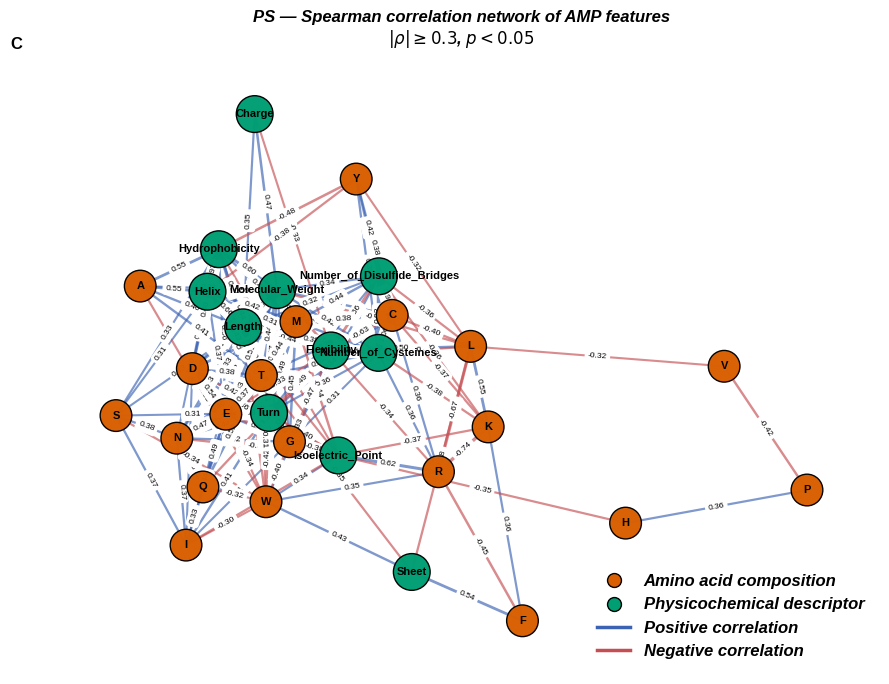


PS
Active samples: 94
Features: 31
Nodes: 31
Edges: 154


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# =========================
# File paths
# =========================
files = {
    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },
    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },
    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test":  "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

aa_color = "#D95F02"
desc_color = "#009E73"
positive_color = "#3B62B3"
negative_color = "#C44E52"

aa_features = list("ACDEFGHIKLMNPQRSTVWY")

# =========================
# Load active features
# =========================
def load_active_features(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])
    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    if "Label" in y.columns:
        y = y["Label"]
    elif "Activity" in y.columns:
        y = y["Activity"]
    else:
        y = y.iloc[:, 0]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    return X[y.astype(int) == 1].copy()

# =========================
# Build Spearman graph
# =========================
def build_graph(X_active, rho_cutoff=0.30, p_cutoff=0.05):

    corr, pvals = spearmanr(X_active)

    corr = pd.DataFrame(
        corr,
        index=X_active.columns,
        columns=X_active.columns
    )

    pvals = pd.DataFrame(
        pvals,
        index=X_active.columns,
        columns=X_active.columns
    )

    G = nx.Graph()

    for feature in X_active.columns:
        G.add_node(feature)

    for i, f1 in enumerate(X_active.columns):
        for j, f2 in enumerate(X_active.columns):
            if j <= i:
                continue

            rho = corr.loc[f1, f2]
            p = pvals.loc[f1, f2]

            if abs(rho) >= rho_cutoff and p < p_cutoff:
                G.add_edge(
                    f1,
                    f2,
                    rho=rho,
                    weight=abs(rho)
                )

    return G

# =========================
# Draw one clear network
# =========================
def draw_clear_network(pathogen):

    info = files[pathogen]
    X_active = load_active_features(info)

    G = build_graph(
        X_active,
        rho_cutoff=0.30,
        p_cutoff=0.05
    )

    # Keep isolated nodes, like your old figure
    pos = nx.spring_layout(
        G,
        seed=42,
        k=1.15,
        iterations=500
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    node_colors = []
    node_sizes = []

    for node in G.nodes():
        if node in aa_features:
            node_colors.append(aa_color)
            node_sizes.append(520)
        else:
            node_colors.append(desc_color)
            node_sizes.append(700)

    positive_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d["rho"] > 0
    ]

    negative_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d["rho"] < 0
    ]

    positive_widths = [
        0.8 + 2.2 * G[u][v]["weight"]
        for u, v in positive_edges
    ]

    negative_widths = [
        0.8 + 2.2 * G[u][v]["weight"]
        for u, v in negative_edges
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=positive_edges,
        ax=ax,
        edge_color=positive_color,
        width=positive_widths,
        alpha=0.65
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=negative_edges,
        ax=ax,
        edge_color=negative_color,
        width=negative_widths,
        alpha=0.65
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=1.0,
        alpha=0.98
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_weight="bold"
    )

    # Edge labels: rho values
    edge_labels = {
        (u, v): f"{d['rho']:.2f}"
        for u, v, d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=6,
        font_color="black",
        rotate=True,
        label_pos=0.5
    )

    ax.set_title(
        f"{info['title']} — Spearman correlation network of AMP features\n"
        r"$|\rho| \geq 0.3$, $p < 0.05$",
        fontsize=12,
        fontstyle="italic",
        fontweight="bold",
        pad=12
    )

    ax.text(
        -0.04,
        1.02,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

    # Legend
    legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Amino acid composition",
            markerfacecolor=aa_color,
            markeredgecolor="black",
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Physicochemical descriptor",
            markerfacecolor=desc_color,
            markeredgecolor="black",
            markersize=10
        ),
        Line2D(
            [0], [0],
            color=positive_color,
            lw=2.5,
            label="Positive correlation"
        ),
        Line2D(
            [0], [0],
            color=negative_color,
            lw=2.5,
            label="Negative correlation"
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower right",
        frameon=False,
        prop={
            "size": 12,
            "style": "italic",
            "weight": "bold"
        }
    )

    plt.tight_layout()

    plt.savefig(f"Figure7{info['panel']}_{pathogen}_Spearman_network.png",
                dpi=600, bbox_inches="tight")
    plt.savefig(f"Figure7{info['panel']}_{pathogen}_Spearman_network.pdf",
                bbox_inches="tight")
    plt.savefig(f"Figure7{info['panel']}_{pathogen}_Spearman_network.svg",
                bbox_inches="tight")

    plt.show()

    print(f"\n{pathogen}")
    print("Active samples:", X_active.shape[0])
    print("Features:", X_active.shape[1])
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

# =========================
# Plot one by one
# =========================
draw_clear_network("KP")
draw_clear_network("EC")
draw_clear_network("PS")

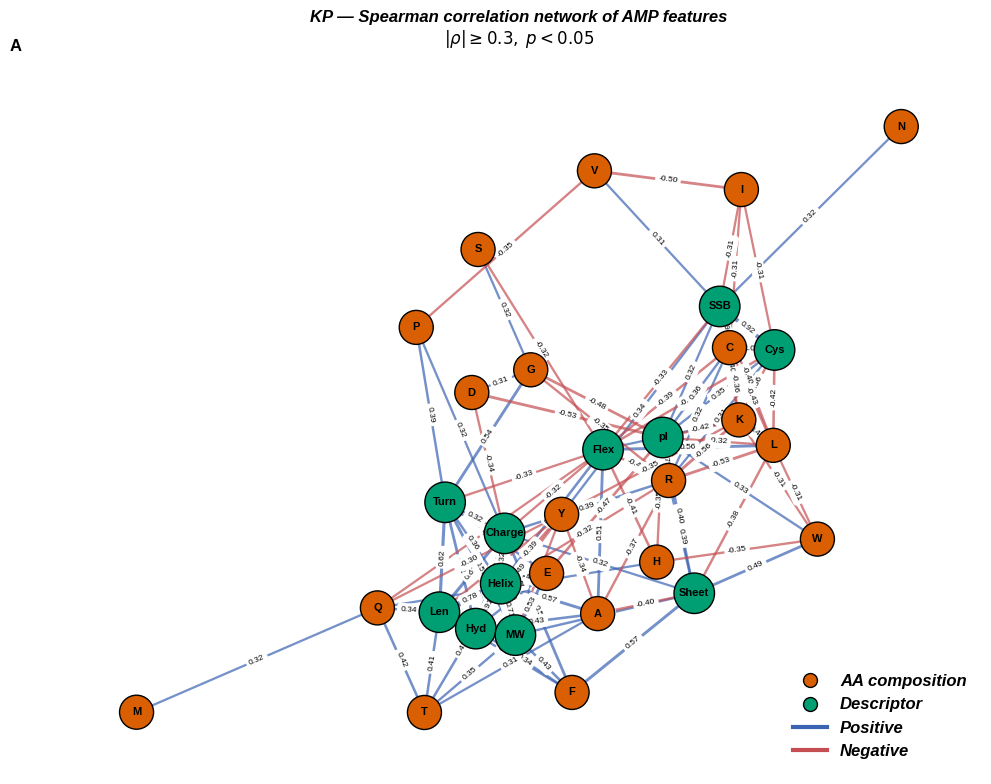

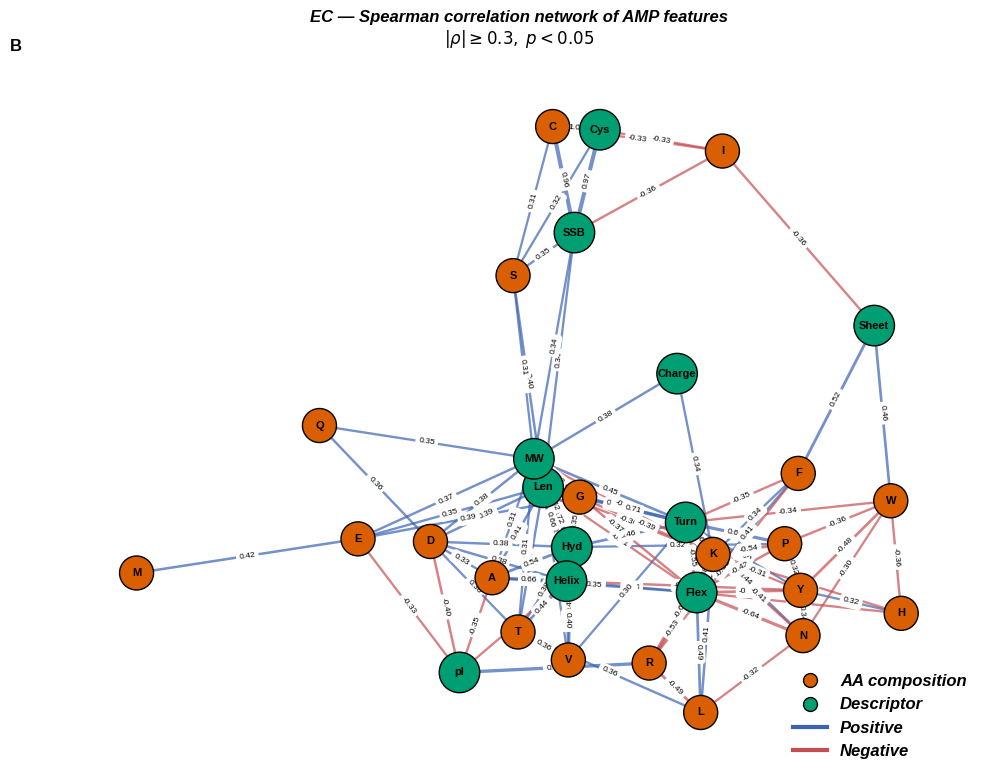

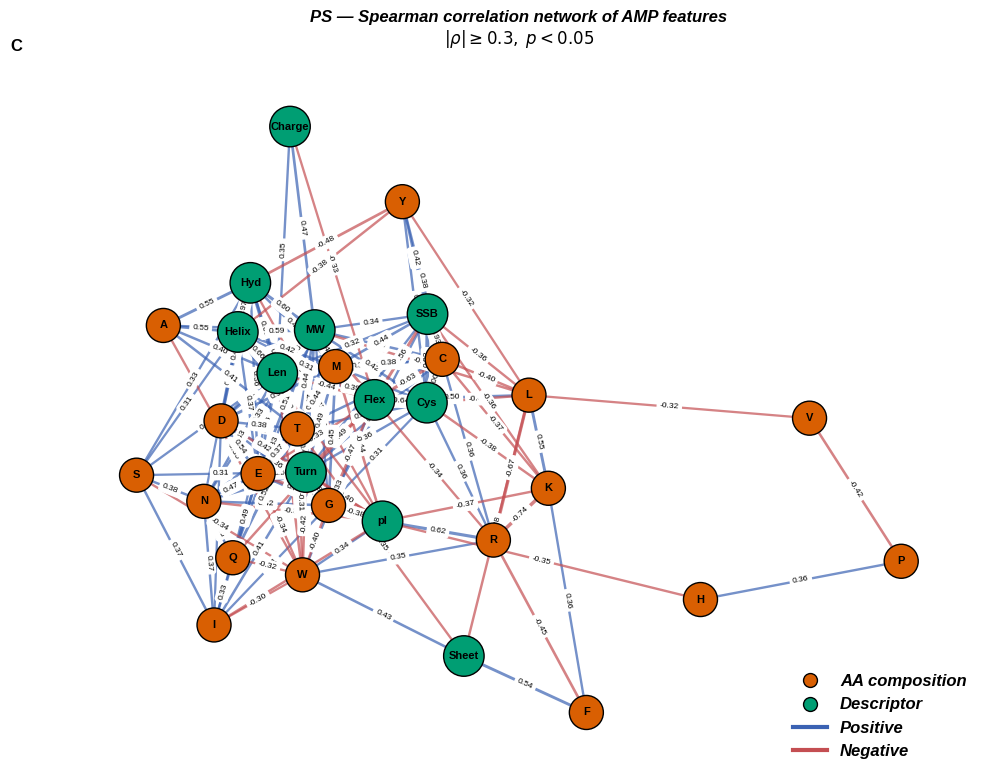

In [32]:
# ============================================
# Figure 7
# Spearman correlation network of AMP features
# Active peptides only
# Publication quality
# ============================================

!pip install -q networkx scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ============================================
# File paths
# ============================================

files = {

    "KP": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_train.csv",
        "X_test": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_train.csv",
        "y_test": "/content/drive/MyDrive/AMP-ML/data/processed/klebsiella/KP_y_test.csv",
        "panel": "A",
        "title": "KP"
    },

    "EC": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_train.csv",
        "X_test": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_train.csv",
        "y_test": "/content/drive/MyDrive/AMP-ML/data/processed/ecoli/EC_y_test.csv",
        "panel": "B",
        "title": "EC"
    },

    "PS": {
        "X_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_train.csv",
        "X_test": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_X_test.csv",
        "y_train": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_train.csv",
        "y_test": "/content/drive/MyDrive/AMP-ML/data/processed/pseudomonas/PS_y_test.csv",
        "panel": "C",
        "title": "PS"
    }
}

# ============================================
# Publication style
# ============================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ============================================
# Colors
# ============================================

AA_COLOR = "#D95F02"
DESC_COLOR = "#009E73"

POS_COLOR = "#3B62B3"
NEG_COLOR = "#C44E52"

# ============================================
# Feature abbreviations
# ============================================

feature_map = {

    "Length": "Len",
    "Molecular_Weight": "MW",
    "Charge": "Charge",
    "Isoelectric_Point": "pI",
    "Hydrophobicity": "Hyd",
    "Flexibility": "Flex",
    "Helix": "Helix",
    "Sheet": "Sheet",
    "Turn": "Turn",
    "Number_of_Cysteines": "Cys",
    "Number_of_Disulfide_Bridges": "SSB"
}

# amino acid nodes

aa_features = [
    "A","C","D","E","F",
    "G","H","I","K","L",
    "M","N","P","Q","R",
    "S","T","V","W","Y"
]

# ============================================
# Load active peptides only
# ============================================

def load_active_features(info):

    X_train = pd.read_csv(info["X_train"])
    X_test = pd.read_csv(info["X_test"])

    y_train = pd.read_csv(info["y_train"])
    y_test = pd.read_csv(info["y_test"])

    X = pd.concat(
        [X_train, X_test],
        ignore_index=True
    )

    y = pd.concat(
        [y_train, y_test],
        ignore_index=True
    )

    if "Label" in y.columns:
        y = y["Label"]

    elif "Activity" in y.columns:
        y = y["Activity"]

    else:
        y = y.iloc[:,0]

    X = X.select_dtypes(include=np.number)

    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X = X.fillna(X.median())

    active_X = X[y.astype(int)==1].copy()

    active_X = active_X.rename(
        columns=feature_map
    )

    return active_X

# ============================================
# Build network
# ============================================

def build_graph(df,
                rho_cutoff=0.30,
                p_cutoff=0.05):

    corr, pvals = spearmanr(df)

    corr = pd.DataFrame(
        corr,
        index=df.columns,
        columns=df.columns
    )

    pvals = pd.DataFrame(
        pvals,
        index=df.columns,
        columns=df.columns
    )

    G = nx.Graph()

    for feature in df.columns:
        G.add_node(feature)

    for i,f1 in enumerate(df.columns):

        for j,f2 in enumerate(df.columns):

            if j <= i:
                continue

            rho = corr.loc[f1,f2]
            p = pvals.loc[f1,f2]

            if abs(rho) >= rho_cutoff and p < p_cutoff:

                G.add_edge(
                    f1,
                    f2,
                    rho=rho,
                    weight=abs(rho)
                )

    return G

# ============================================
# Draw network
# ============================================

def draw_network(pathogen):

    info = files[pathogen]

    X_active = load_active_features(info)

    G = build_graph(X_active)

    pos = nx.spring_layout(
        G,
        seed=42,
        k=1.15,
        iterations=500
    )

    fig, ax = plt.subplots(
        figsize=(10,8)
    )

    # node colors

    node_colors = []
    node_sizes = []

    for node in G.nodes():

        if node in aa_features:

            node_colors.append(AA_COLOR)
            node_sizes.append(600)

        else:

            node_colors.append(DESC_COLOR)
            node_sizes.append(850)

    # positive edges

    pos_edges = [
        (u,v)
        for u,v,d in G.edges(data=True)
        if d["rho"] > 0
    ]

    neg_edges = [
        (u,v)
        for u,v,d in G.edges(data=True)
        if d["rho"] < 0
    ]

    pos_width = [
        1 + 2*d["weight"]
        for u,v,d in G.edges(data=True)
        if d["rho"] > 0
    ]

    neg_width = [
        1 + 2*d["weight"]
        for u,v,d in G.edges(data=True)
        if d["rho"] < 0
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=pos_edges,
        edge_color=POS_COLOR,
        width=pos_width,
        alpha=0.7,
        ax=ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=neg_edges,
        edge_color=NEG_COLOR,
        width=neg_width,
        alpha=0.7,
        ax=ax
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=1,
        ax=ax
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8,
        font_weight="bold"
    )

    edge_labels = {
        (u,v):f"{d['rho']:.2f}"
        for u,v,d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=6
    )

    ax.set_title(
        f"{info['title']} — Spearman correlation network of AMP features\n"
        r"$|\rho| \geq 0.3,\; p < 0.05$",
        fontsize=12,
        fontweight="bold",
        fontstyle="italic",
        pad=15
    )

    ax.text(
        -0.05,
        1.02,
        info["panel"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    legend_items = [

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=AA_COLOR,
            markeredgecolor='black',
            markersize=10,
            label='AA composition'
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=DESC_COLOR,
            markeredgecolor='black',
            markersize=10,
            label='Descriptor'
        ),

        Line2D(
            [0],[0],
            color=POS_COLOR,
            lw=3,
            label='Positive'
        ),

        Line2D(
            [0],[0],
            color=NEG_COLOR,
            lw=3,
            label='Negative'
        )
    ]

    ax.legend(
        handles=legend_items,
        frameon=False,
        loc="lower right",
        prop={
            "size":12,
            "style":"italic",
            "weight":"bold"
        }
    )

    ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"{pathogen}_Spearman_network.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{pathogen}_Spearman_network.pdf",
        bbox_inches="tight"
    )

    plt.savefig(
        f"{pathogen}_Spearman_network.svg",
        bbox_inches="tight"
    )

    plt.show()

# ============================================
# Generate figures
# ============================================

draw_network("KP")
draw_network("EC")
draw_network("PS")